# Rule occurrence overview

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (folder / "result_summary" / "data_helper.py").exists()
)
sys.path[:0] = [str(ROOT / "result_summary")]

import data_helper as dh
import rule_metrics as rm
from data_helper import METADATA_COLS
from vis_helper import (
    plot_metric_vs_abundance,
    plot_patient_fingerprint,
    plot_rule_metric_scatter,
    plot_rule_stage_heatmap,
)

warnings.filterwarnings("ignore")

RULE_MAX_ITEMS = 2
SCORE = "Clinical score"
STAGES = ["Control", "Mild", "Severe"]
TOP_RULES = 30
TOP_PER_FOV = 10
MIN_ELIGIBLE = 2
USE_CELL_ELIGIBILITY = True
RULE_SCOPE = f"Rule kind: attraction · Rule size: pairwise · Mining FDR: ≤0.05 · Max items: {RULE_MAX_ITEMS}"

DROP_VALUES = {"Donor type": ["MMUD"]}
METADATA_ORDER = {
    "Days after Transplant grouped": ["Control", "<30", "30-100", ">100"],
    "Donor type": ["Control", "Sibling", "MUD", "Haplo"],
    "Cortico Response": ["Control", "Responder", "Non-responder"],
    "Survival at follow-up": ["Control", "Survived", "Not survived"],
}

def figure_name(*parts):
    """One stable file name per heatmap or fingerprint."""
    tag = "_".join(str(p).replace(" ", "") for p in parts if p)
    return f"overview_{tag}.pdf"

## Data

In [2]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS, kind="attracts")
rules = dh.prepare_rules(df_results)
rules = rules[rules["FOV"].isin(df_fovs["FOV"])]

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9647 rules naming no Unidentified.
Kept 4100 rules (max_items=2, kind=attracts).


## Logic

In [3]:
def find_top_rules(rows, top_n=5):
    table = rows.copy()
    table["Support_n"] = table["Support"]
    table["Lift_n"] = 1 - 1 / table["Lift"].clip(lower=1)
    table["Confidence_n"] = table["Confidence"]
    table["Conviction_n"] = 1 - 1 / table["Conviction"].clip(lower=1)
    count = np.log1p(table["Rule_Count_Global"])
    table["Count_n"] = count / count.max() if count.max() else 0
    table["Significance_Score"] = (
        .40 * table["Support_n"] + .15 * table["Lift_n"]
        + .15 * table["Confidence_n"] + .20 * table["Conviction_n"]
        + .10 * table["Count_n"]
    )
    return (
        table.sort_values("Significance_Score", ascending=False)
        .drop_duplicates(["Antecedents", "Consequents"])
        .head(top_n)
    )

In [4]:
def aggregate_top_rules(metadata, score, top_n=TOP_PER_FOV, organs=None, id_col="FOV"):
    meta = metadata.copy()
    rows = rules.copy()
    if organs is not None:
        meta = meta[meta["Organ"].isin(organs)]
        rows = rows[rows["FOV"].isin(meta["FOV"])]
    meta = meta[meta["FOV"].isin(rows["FOV"])]

    selected_rows = [find_top_rules(group, top_n) for _, group in rows.groupby("FOV")]
    if not selected_rows:
        return pd.DataFrame(), meta, pd.Series(dtype=object), pd.DataFrame()
    selected = set(pd.concat(selected_rows)["Clean_Rule"])
    rows = rows[rows["Clean_Rule"].isin(selected)].copy()

    meta_cols = ["FOV", score] + ([id_col] if id_col != "FOV" else [])
    stale = [column for column in (score, id_col) if column != "FOV" and column in rows]
    merged = rows.drop(columns=stale).merge(meta[meta_cols], on="FOV", how="left")
    total = merged.groupby("Clean_Rule")[id_col].nunique().rename(f"Total {id_col}")
    stages = merged.groupby(["Clean_Rule", score])[id_col].nunique().unstack(fill_value=0)
    occurrence = pd.concat([total, stages], axis=1).fillna(0).astype(int)
    occurrence = occurrence.sort_values(f"Total {id_col}", ascending=False)
    rule_fovs = merged.groupby("Clean_Rule")["FOV"].unique()
    return occurrence, meta, rule_fovs, merged

In [5]:
def rule_abundance(rule_fovs, side, fractions):
    values = {}
    for rule, fovs in rule_fovs.items():
        ant, con = rule.split(" -> ")
        cell_types = (ant if side == "ant" else con).split(", ")
        rows = fractions.index.intersection(fovs)
        values[rule] = fractions.loc[rows, cell_types].mean(axis=1).mean()
    return pd.Series(values)

In [6]:
def build_rule_table(rows, with_abundance=False, score=None):
    grouped = rows.groupby("Clean_Rule")
    metrics = [name for name in ("Lift", "Confidence", "Conviction", "Support", "FDR") if name in rows]
    table = grouped[metrics].median().add_prefix("med_")
    rule_fovs = grouped["FOV"].unique()
    fov_to_biopsy = df_fovs.set_index("FOV")["Biopsy"]
    fov_to_patient = df_fovs.set_index("FOV")["PatientID"]
    table["n_FOV"] = rule_fovs.apply(lambda x: len(set(x)))
    table["n_Biopsy"] = rule_fovs.apply(lambda x: fov_to_biopsy.reindex(x).nunique())
    table["n_Patient"] = rule_fovs.apply(lambda x: fov_to_patient.reindex(x).nunique())
    sides = table.index.to_series().str.split(" -> ", n=1, expand=True)
    table.insert(0, "antecedent", sides[0].values)
    table.insert(1, "consequent", sides[1].values)
    if score:
        fov_to_stage = df_fovs.set_index("FOV")[score]
        table["top_stage"] = rule_fovs.apply(
            lambda x: fov_to_stage.reindex(x).dropna().mode().iloc[0]
        )
    if with_abundance:
        table["ant_abund"] = rule_abundance(rule_fovs, "ant", FOV_FRAC)
        table["con_abund"] = rule_abundance(rule_fovs, "con", FOV_FRAC)
    return table

In [7]:
def show_heatmap(score=SCORE, organs=None, id_col="FOV", stage_order=None,
                 show_abundance=False, show_metrics=False, sort_by="prevalence",
                 drop_values=None, save=None):
    meta = df_fovs.dropna(subset=[score])
    if drop_values:
        meta = meta[~meta[score].isin(drop_values)]
    occurrence, meta, rule_fovs, merged = aggregate_top_rules(
        meta, score, organs=organs, id_col=id_col
    )
    abundance = pd.DataFrame({
        side: rule_abundance(rule_fovs, side, FOV_FRAC)
        for side in ("ant", "con")
    })
    if sort_by in ("ant", "con", "both"):
        key = abundance.mean(1) if sort_by == "both" else abundance[sort_by]
        occurrence = occurrence.reindex(key.sort_values(ascending=False).index).dropna(how="all")
    plot_rule_stage_heatmap(
        occurrence, meta, score, organs=organs, id_col=id_col,
        stage_order=stage_order or STAGES,
        rule_abundance=abundance if show_abundance else None,
        max_rules_to_show=TOP_RULES,
        scope=f"{RULE_SCOPE} · Eligibility: none",
        save=save or figure_name("prevalence", score.split()[0].lower(), id_col,
                                 organs[0] if organs else "bothorgans", sort_by),
    )
    if show_metrics:
        table = build_rule_table(merged, show_abundance, score)
        display(table.reindex(occurrence.head(TOP_RULES).index).round(3))
    return occurrence

In [8]:
def patient_fingerprint(rule_fovs, metadata, rules_to_show=None):
    fov_to_patient = metadata.set_index("FOV")["PatientID"]
    totals = metadata.groupby("PatientID")["FOV"].nunique()
    totals = totals[totals >= MIN_ELIGIBLE]
    matrix = pd.DataFrame({
        rule: fov_to_patient.reindex(fovs).dropna().value_counts() / totals
        for rule, fovs in rule_fovs.items()
    }).T.reindex(columns=totals.index).fillna(0)
    return matrix.reindex(rules_to_show).dropna(how="all") if rules_to_show is not None else matrix

In [9]:
def fov_fingerprint(merged, metadata, rules_to_show=None, metric="Lift"):
    matrix = np.log2(merged.pivot_table(index="Clean_Rule", columns="FOV", values=metric))
    keep = metadata.groupby("PatientID")["FOV"].transform("nunique") >= MIN_ELIGIBLE
    order = metadata[keep].sort_values(["PatientID", "FOV"])["FOV"]
    matrix = matrix.reindex(columns=[fov for fov in order if fov in matrix])
    return matrix.reindex(rules_to_show).dropna(how="all") if rules_to_show is not None else matrix

In [10]:
def show_fingerprint(score=SCORE, organs=None, order="cluster", by="patient",
                     cluster_rules=False, show_consistency=False, save=None):
    occurrence, meta, rule_fovs, merged = aggregate_top_rules(
        df_fovs, score, organs=organs, id_col="PatientID"
    )
    rules_to_show = occurrence.head(TOP_RULES).index
    matrix = (
        fov_fingerprint(merged, meta, rules_to_show)
        if by == "fov"
        else patient_fingerprint(rule_fovs, meta, rules_to_show)
    )
    consistency = matrix.where(matrix > 0).mean(1) if show_consistency else None
    plot_patient_fingerprint(
        matrix, meta, score, consistency=consistency,
        patient_col="FOV" if by == "fov" else "PatientID",
        stage_order=STAGES, order=order, cluster_rules=cluster_rules,
        max_rules=TOP_RULES, by=by,
        scope=f"{RULE_SCOPE} · Organ: {', '.join(organs) if organs else 'Colon / Duodenum'} · Eligibility: none",
        save=save or figure_name("fingerprint", by, score.split()[0].lower(),
                                 organs[0] if organs else "bothorgans"),
    )
    return matrix

In [11]:
def rule_items(rows):
    first = rows.drop_duplicates("Clean_Rule").set_index("Clean_Rule")
    return {rule: (row["Antecedents"], row["Consequents"]) for rule, row in first.iterrows()}

In [12]:
def eligible_occurrence(organ, id_col="FOV"):
    meta = df_fovs[(df_fovs["Organ"] == organ) & df_fovs[SCORE].notna()].copy()
    raw, _, _, rows = aggregate_top_rules(meta, SCORE, organs=[organ], id_col=id_col)
    selected = raw.head(TOP_RULES).index
    mask = rm.testable_fovs(rule_items(canon), df_cells, kinds=(rm.ATTRACTS,)).reindex(
        index=selected, columns=meta["FOV"], fill_value=False
    )
    columns = [f"Total {id_col}", *[stage for stage in STAGES if stage in set(meta[SCORE])]]
    found = pd.DataFrame(0, index=selected, columns=columns)
    eligible = found.copy()
    for rule in selected:
        measurable = meta[meta["FOV"].isin(mask.columns[mask.loc[rule]])]
        hits = rows.loc[rows["Clean_Rule"] == rule, "FOV"]
        detected = measurable[measurable["FOV"].isin(hits)]
        for column in columns:
            can_measure = measurable if column.startswith("Total") else measurable[measurable[SCORE] == column]
            has_rule = detected if column.startswith("Total") else detected[detected[SCORE] == column]
            eligible.loc[rule, column] = can_measure[id_col].nunique()
            found.loc[rule, column] = has_rule[id_col].nunique()
    order = found[columns[0]].div(eligible[columns[0]].replace(0, np.nan)).sort_values(ascending=False).index
    return found.loc[order], eligible.loc[order], rows, meta, mask

In [13]:
def eligible_patient_fingerprint(rows, meta, selected, mask):
    patients = sorted(meta["PatientID"].dropna().unique(), key=str)
    matrix = pd.DataFrame(np.nan, index=selected, columns=patients)
    for rule in selected:
        measurable = meta[meta["FOV"].isin(mask.columns[mask.loc[rule]])]
        totals = measurable.groupby("PatientID")["FOV"].nunique()
        totals = totals[totals >= MIN_ELIGIBLE]
        hits = rows.loc[rows["Clean_Rule"] == rule, "FOV"]
        counts = measurable[measurable["FOV"].isin(hits)].groupby("PatientID")["FOV"].nunique()
        matrix.loc[rule, totals.index] = counts.reindex(totals.index, fill_value=0) / totals
    return matrix.dropna(axis=1, how="all")

In [14]:
FOV_FRAC = dh.fov_fractions(df_cells)
canon = rules[rules["state"] > 0].copy()
rule_table = build_rule_table(canon, with_abundance=True, score=SCORE)

## Occurrence by counting unit, score and organ

saved summary_downloads\overview_prevalence_clinical_FOV_bothorgans_prevalence.pdf


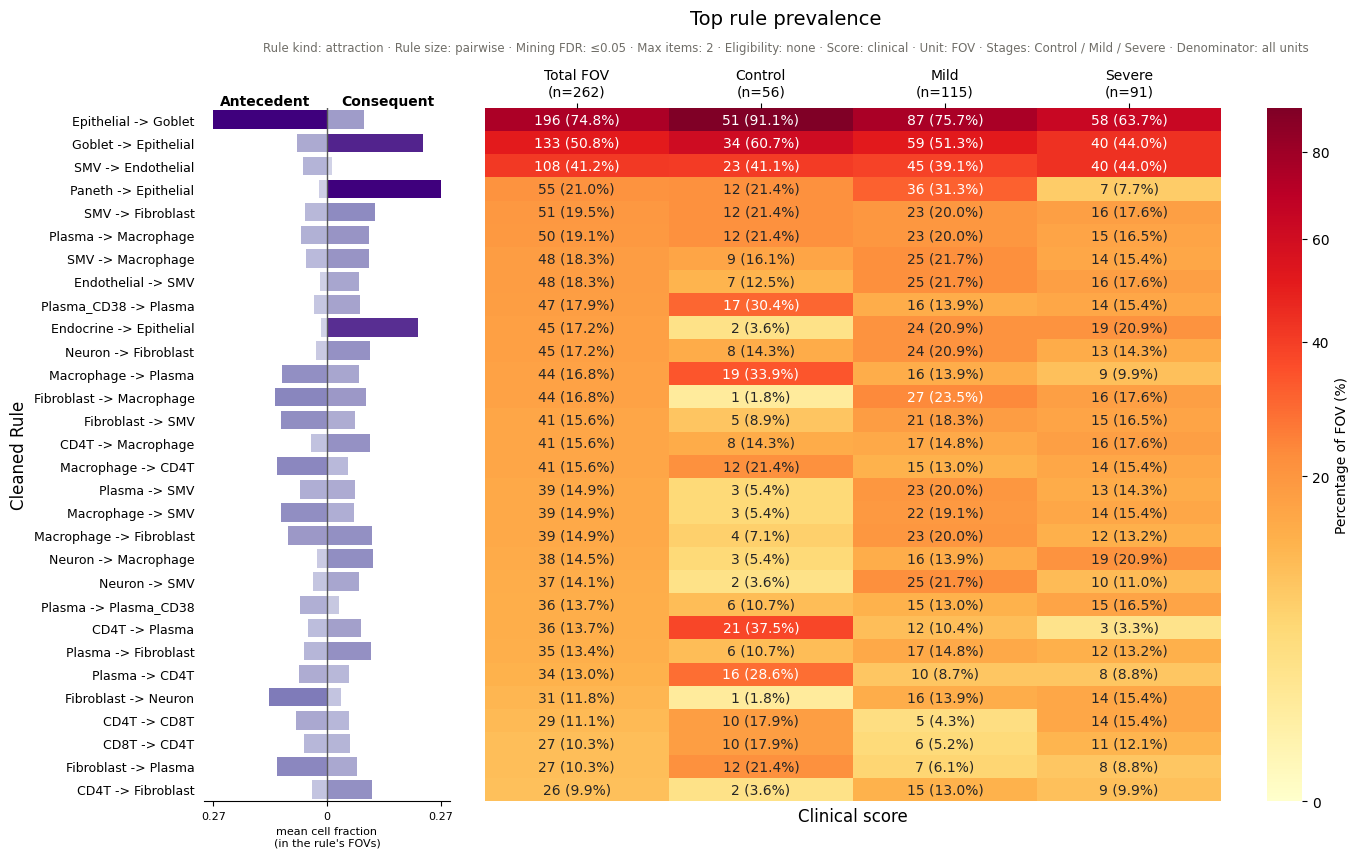

saved summary_downloads\overview_prevalence_clinical_Biopsy_bothorgans_prevalence.pdf


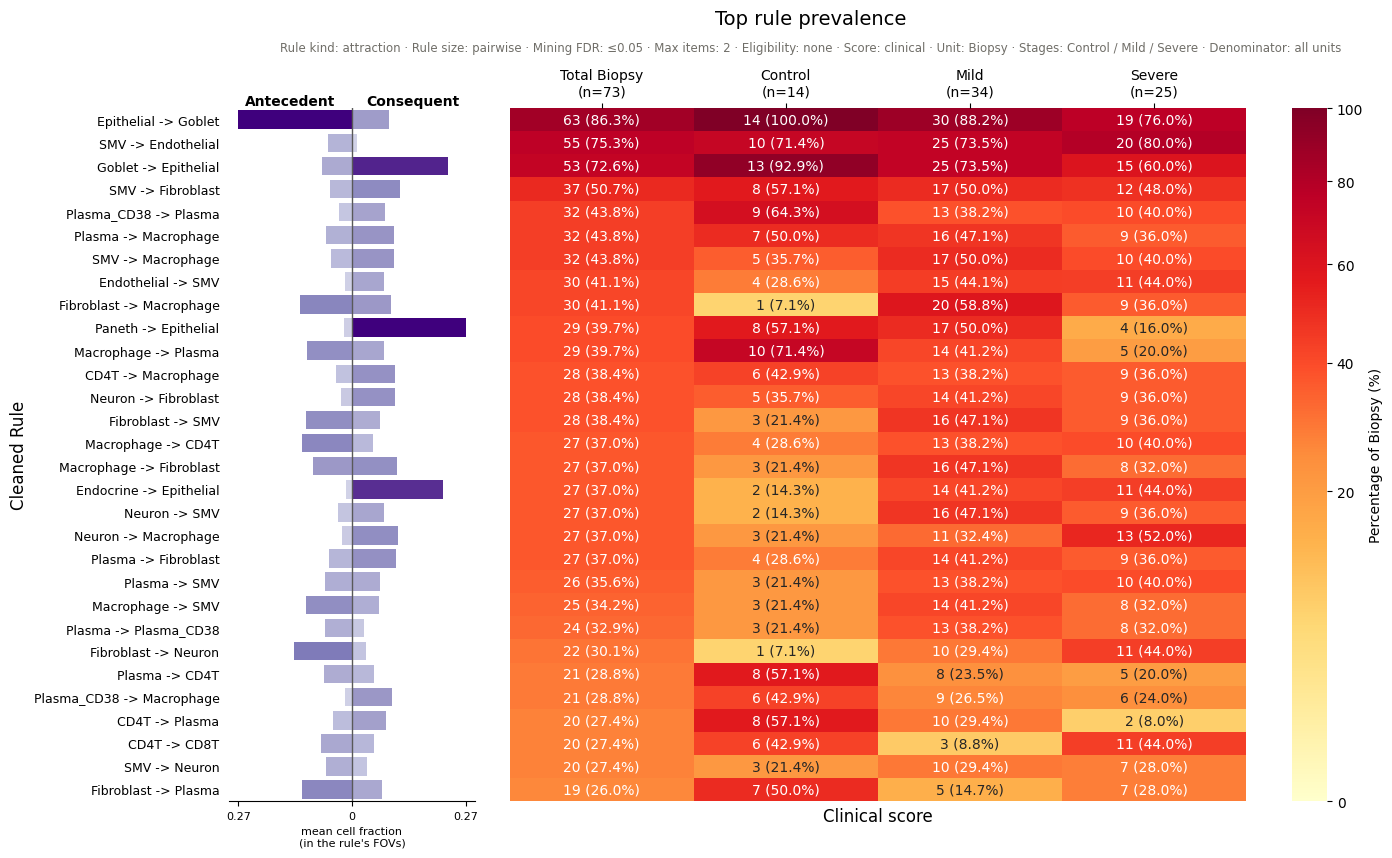

saved summary_downloads\overview_prevalence_clinical_PatientID_bothorgans_prevalence.pdf


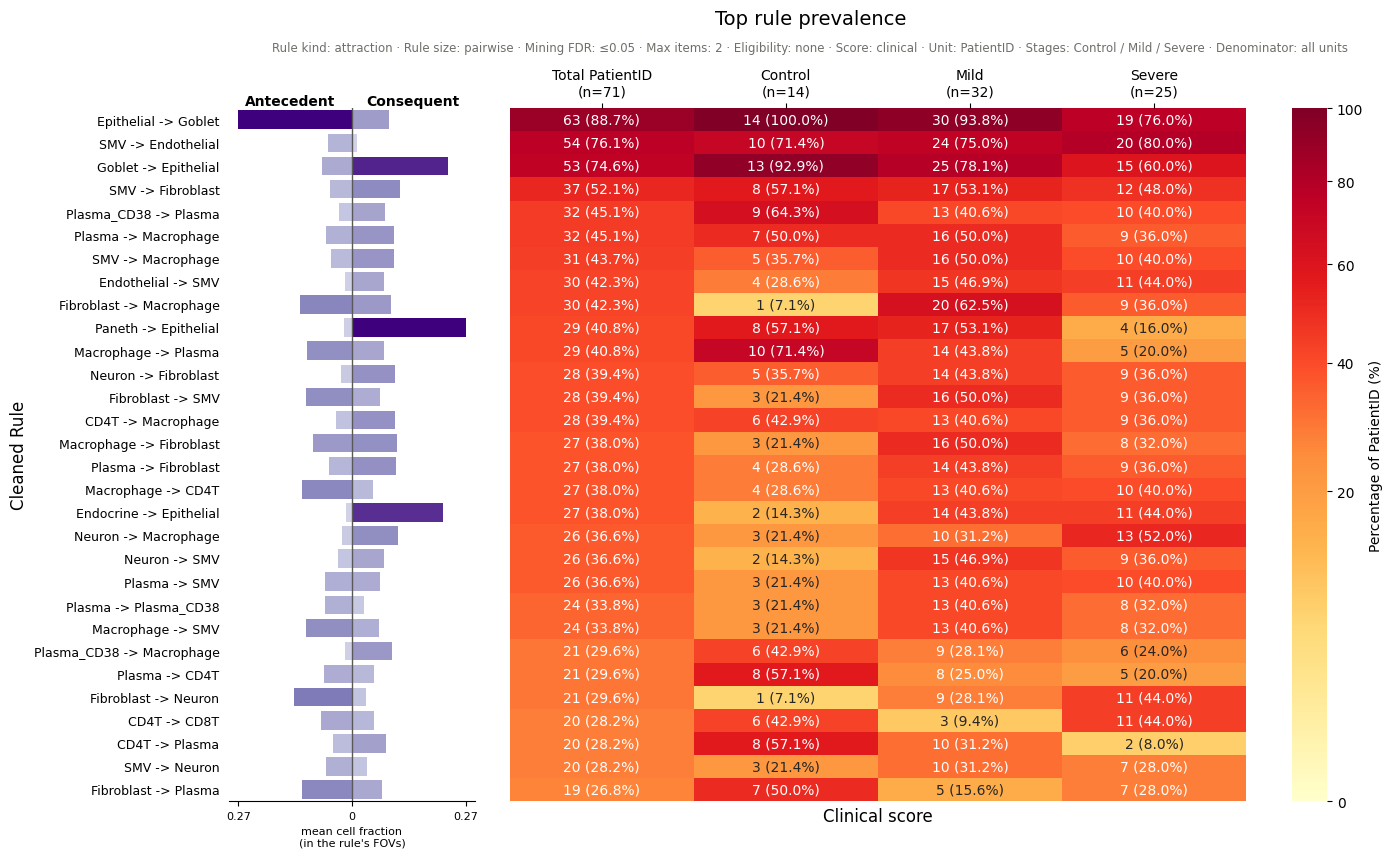

saved summary_downloads\overview_prevalence_clinical_FOV_bothorgans_prevalence.pdf


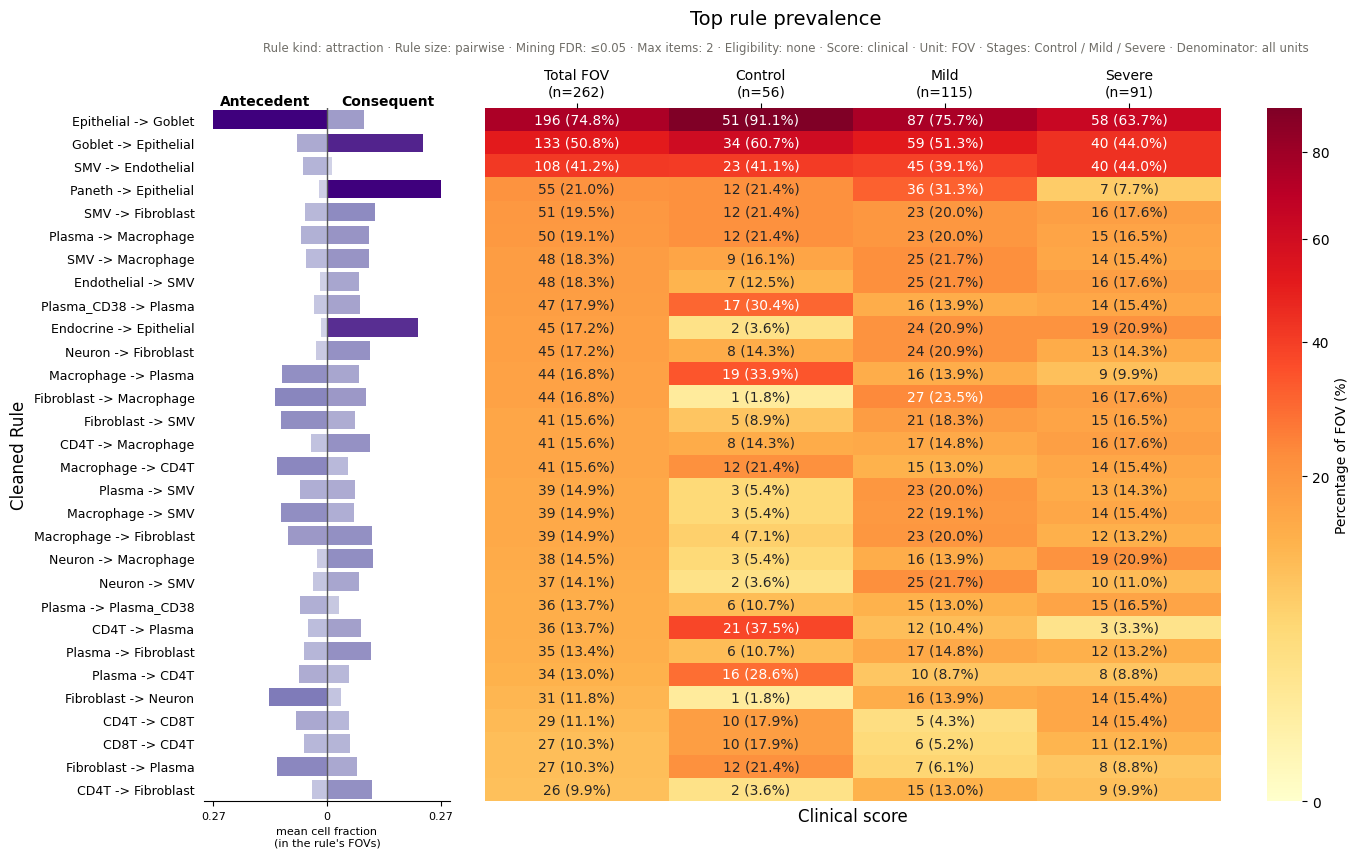

saved summary_downloads\overview_prevalence_clinical_FOV_Colon_prevalence.pdf


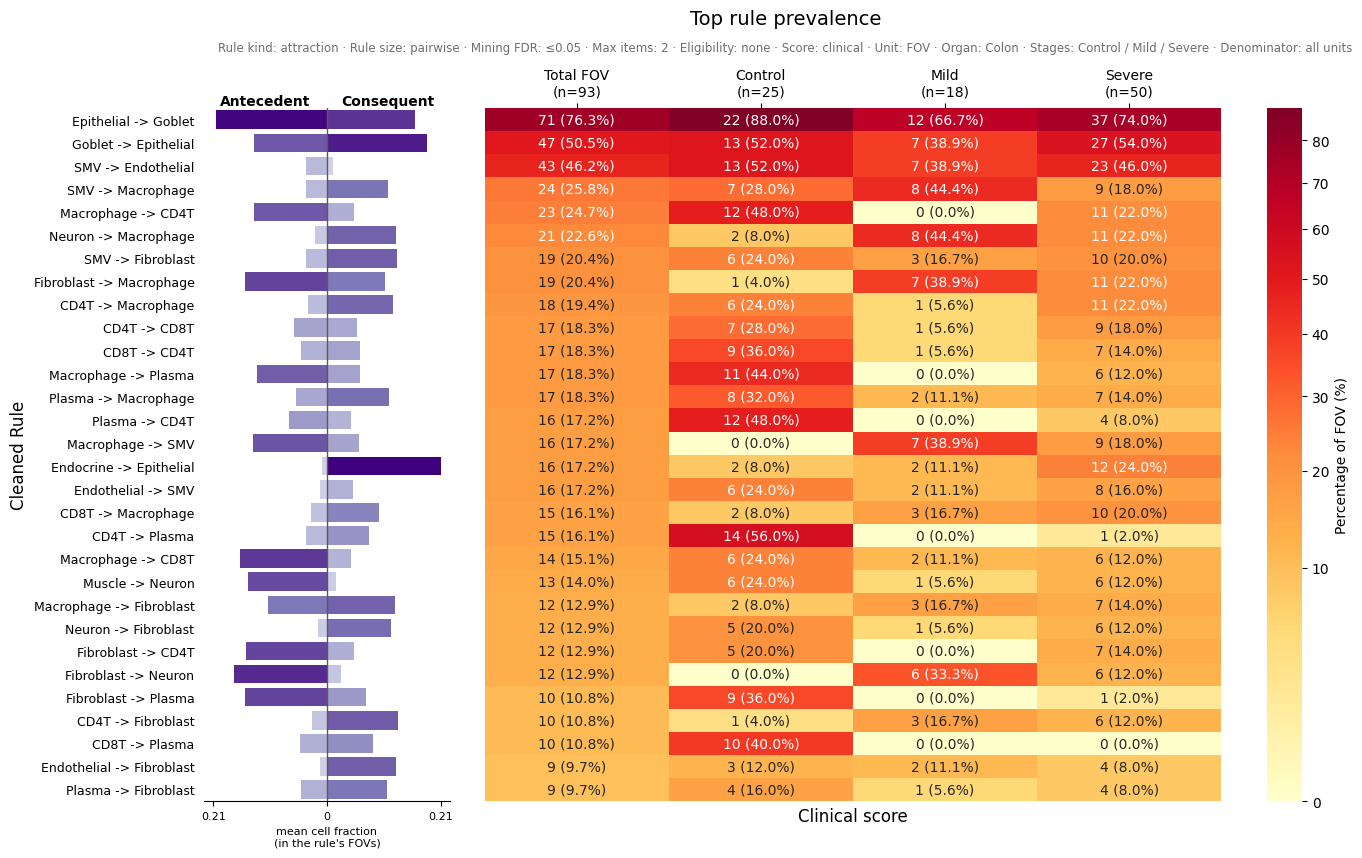

saved summary_downloads\overview_prevalence_clinical_FOV_Duodenum_prevalence.pdf


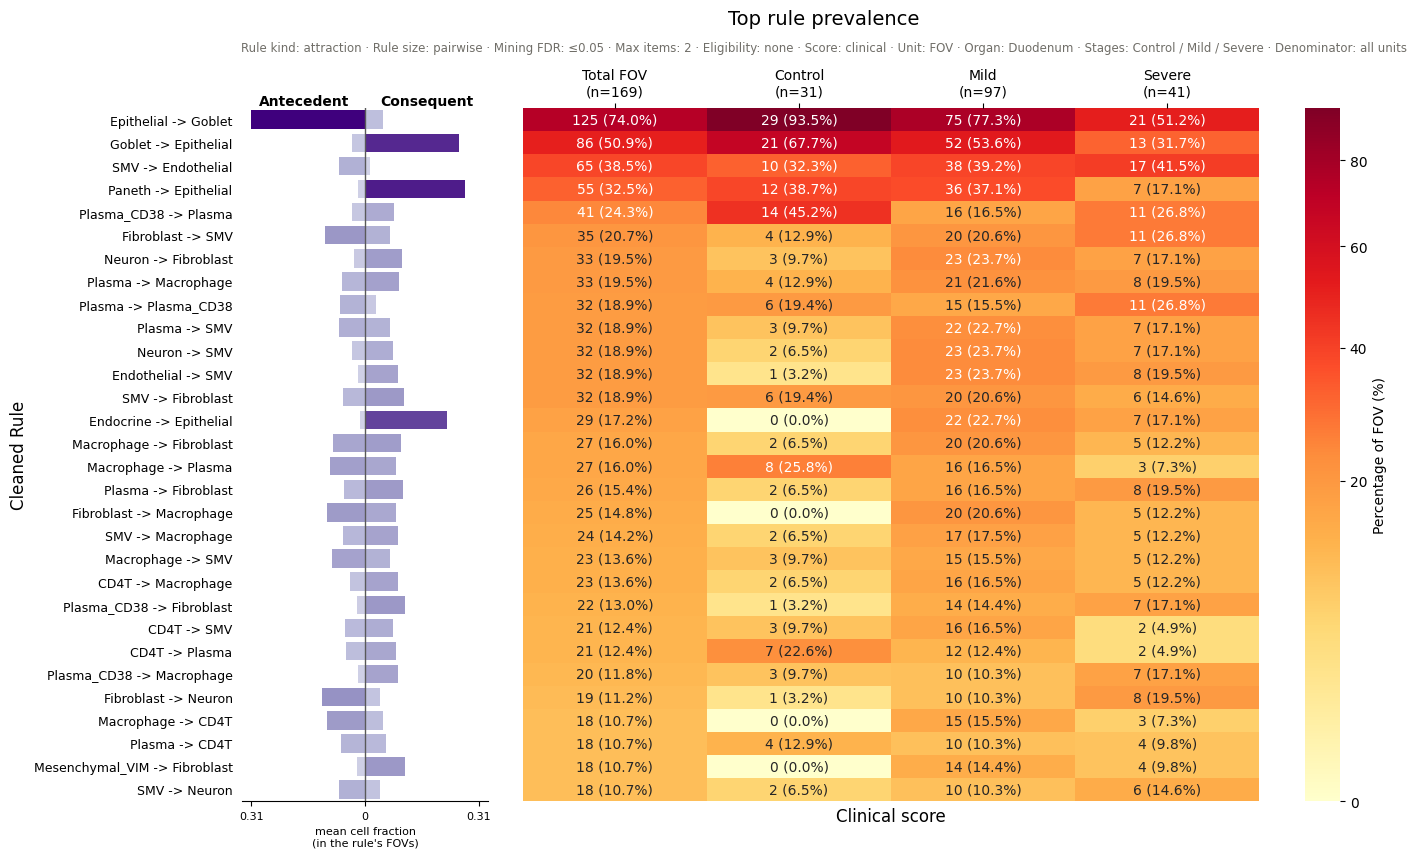

In [15]:
for unit in ("FOV", "Biopsy", "PatientID"):
    show_heatmap(show_abundance=True, id_col=unit)
show_heatmap(score="Clinical score", show_abundance=True)
for organ in ("Colon", "Duodenum"):
    show_heatmap(organs=[organ], show_abundance=True)

## Rule metrics

saved summary_downloads\overview_prevalence_clinical_PatientID_bothorgans_prevalence.pdf


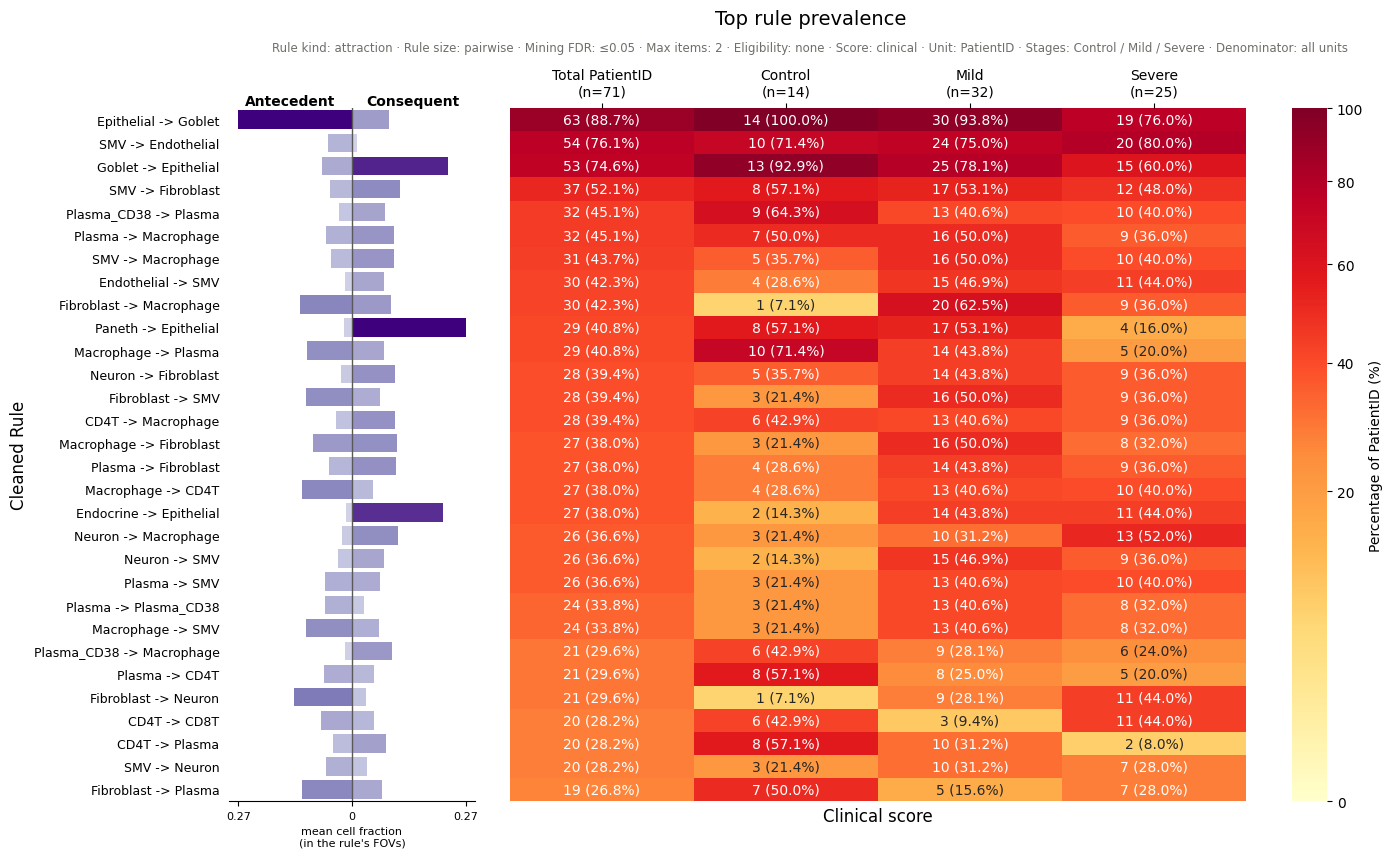

,antecedent,consequent,med_Lift,med_Confidence,med_Conviction,med_Support,n_FOV,n_Biopsy,n_Patient,top_stage,ant_abund,con_abund
Clean_Rule,,,,,,,,,,,,
Epithelial -> Goblet,Epithelial,Goblet,1.745,0.765,2.357,0.202,196,63,63,Mild,0.270,0.089
SMV -> Endothelial,SMV,Endothelial,2.393,0.602,1.822,0.032,108,55,54,Mild,0.057,0.013
Goblet -> Epithelial,Goblet,Epithelial,1.402,0.995,48.346,0.045,133,53,53,Mild,0.070,0.229
SMV -> Fibroblast,SMV,Fibroblast,1.244,0.957,5.682,0.049,51,37,37,Mild,0.051,0.114
Plasma_CD38 -> Plasma,Plasma_CD38,Plasma,1.404,0.889,3.311,0.027,47,32,32,Control,0.032,0.078
Plasma -> Macrophage,Plasma,Macrophage,1.258,0.965,6.688,0.062,50,32,32,Mild,0.061,0.099
SMV -> Macrophage,SMV,Macrophage,1.259,0.936,4.309,0.046,48,32,31,Mild,0.049,0.100
Endothelial -> SMV,Endothelial,SMV,1.447,0.925,5.485,0.014,48,30,30,Mild,0.016,0.076
Fibroblast -> Macrophage,Fibroblast,Macrophage,1.254,0.902,3.033,0.119,44,30,30,Mild,0.122,0.093


,Total PatientID,Control,Mild,Severe
Clean_Rule,,,,
Epithelial -> Goblet,63,14,30,19
SMV -> Endothelial,54,10,24,20
Goblet -> Epithelial,53,13,25,15
SMV -> Fibroblast,37,8,17,12
Plasma_CD38 -> Plasma,32,9,13,10
...,...,...,...,...
CD4T -> Goblet,1,0,0,1
Plasma -> Paneth,1,0,1,0
CD4T -> ImmuneOther_CD45RA,1,0,0,1


In [16]:
show_heatmap(id_col="PatientID", show_abundance=True, show_metrics=True)

## FOV fingerprints

saved summary_downloads\overview_fingerprint_fov_clinical_Colon.pdf


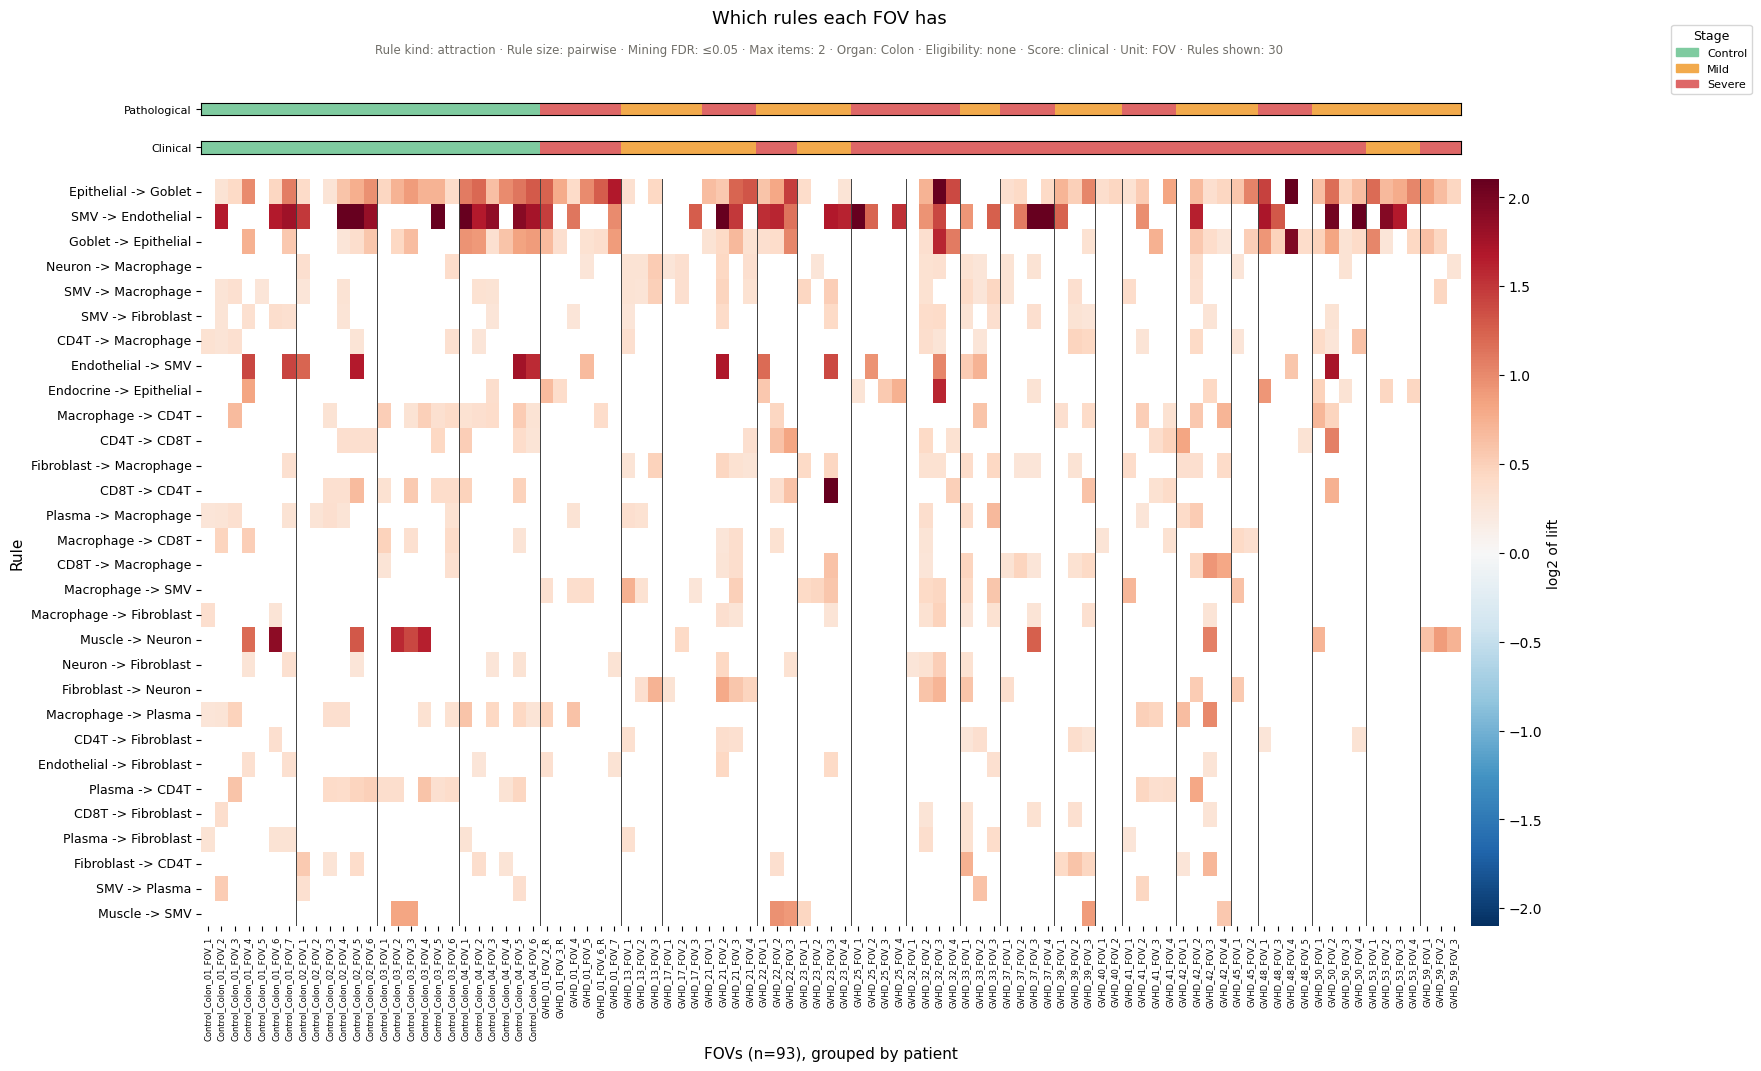

saved summary_downloads\overview_fingerprint_fov_clinical_Duodenum.pdf


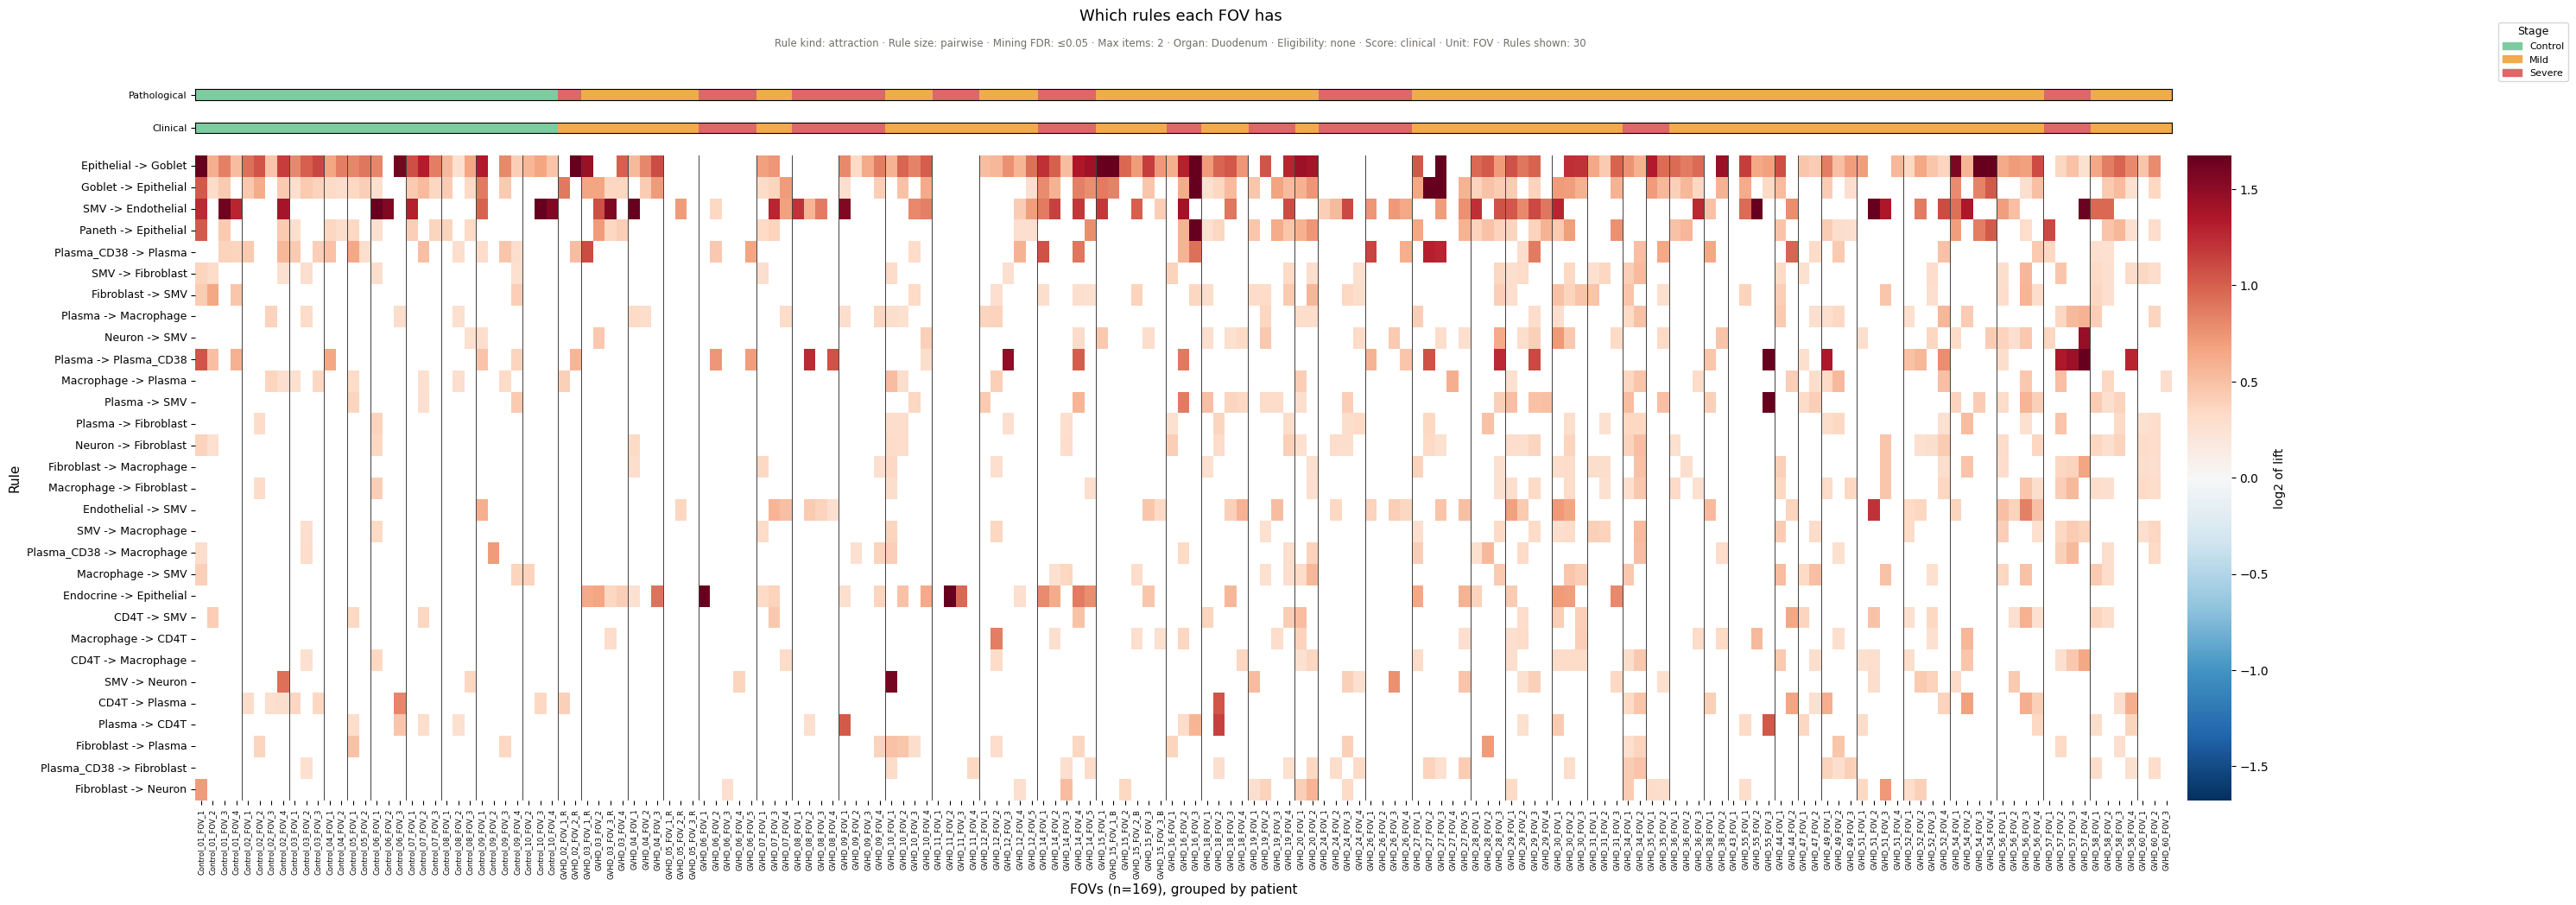

In [17]:
for organ in ("Colon", "Duodenum"):
    show_fingerprint(by="fov", organs=[organ])

## Biopsy metadata

saved summary_downloads\overview_prevalence_days_FOV_Colon_prevalence.pdf


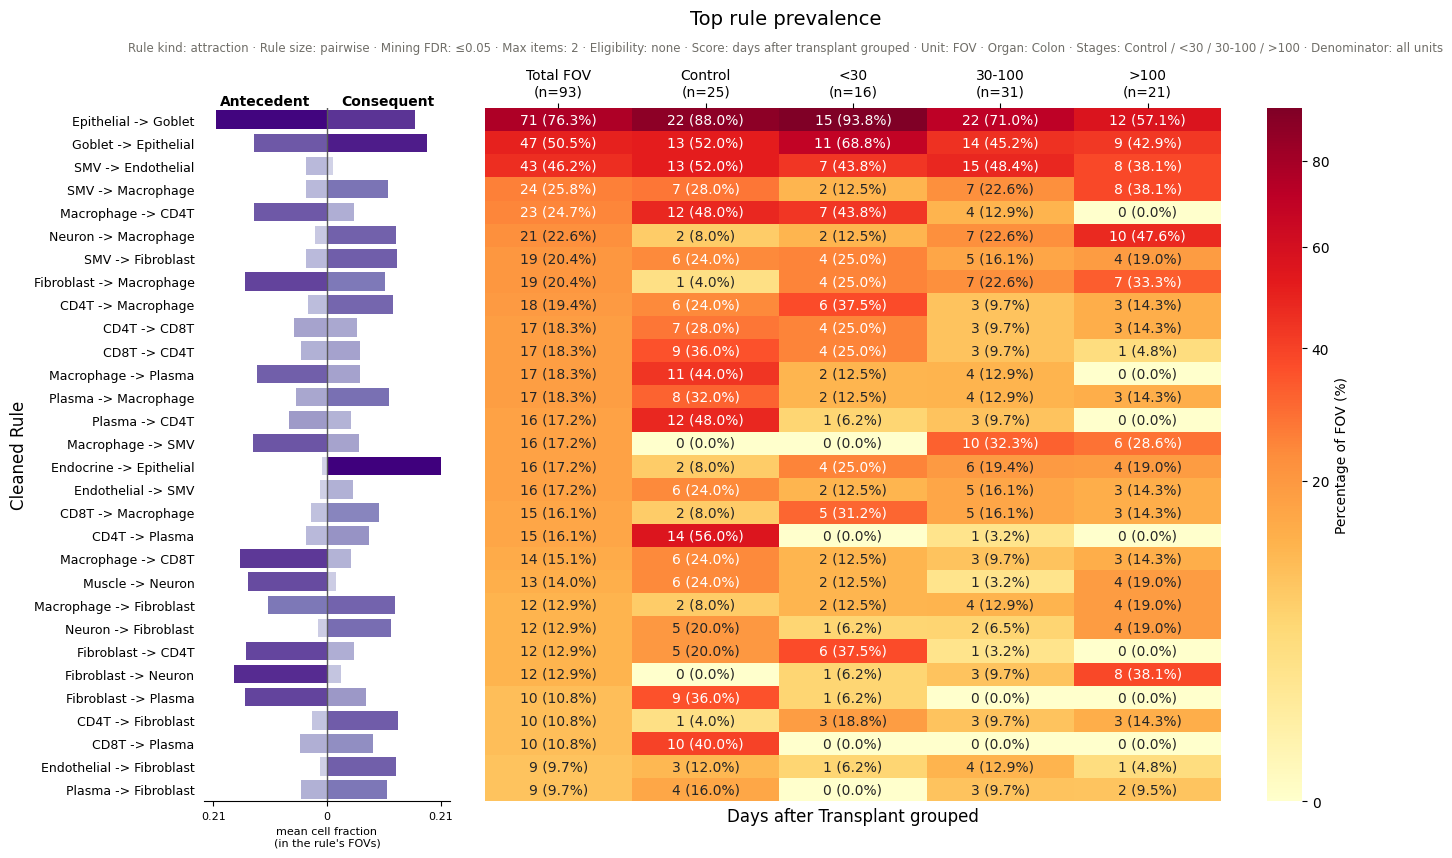

saved summary_downloads\overview_prevalence_days_FOV_Duodenum_prevalence.pdf


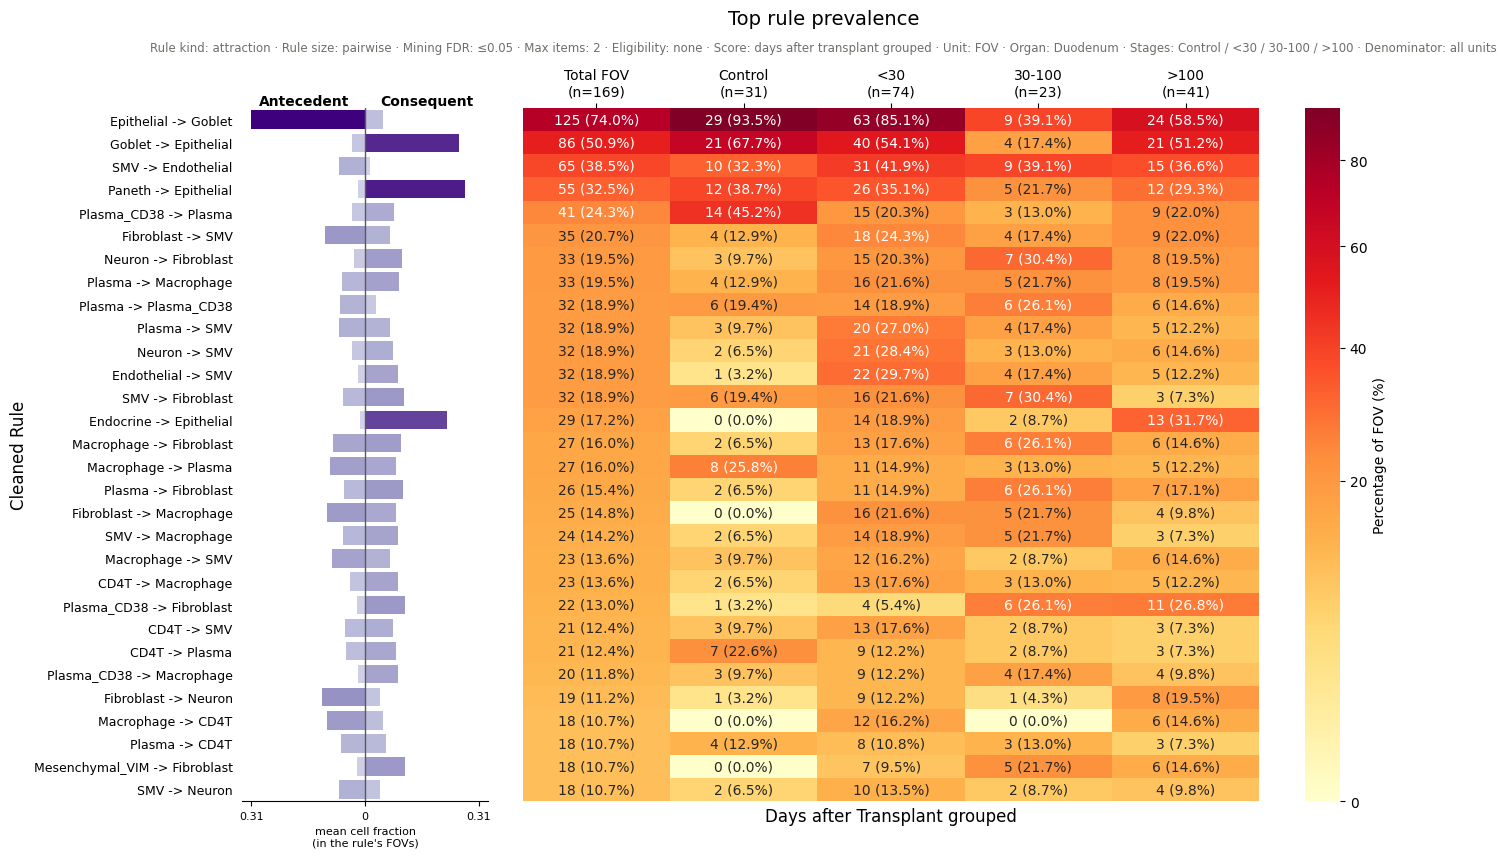

saved summary_downloads\overview_prevalence_donor_FOV_Colon_prevalence.pdf


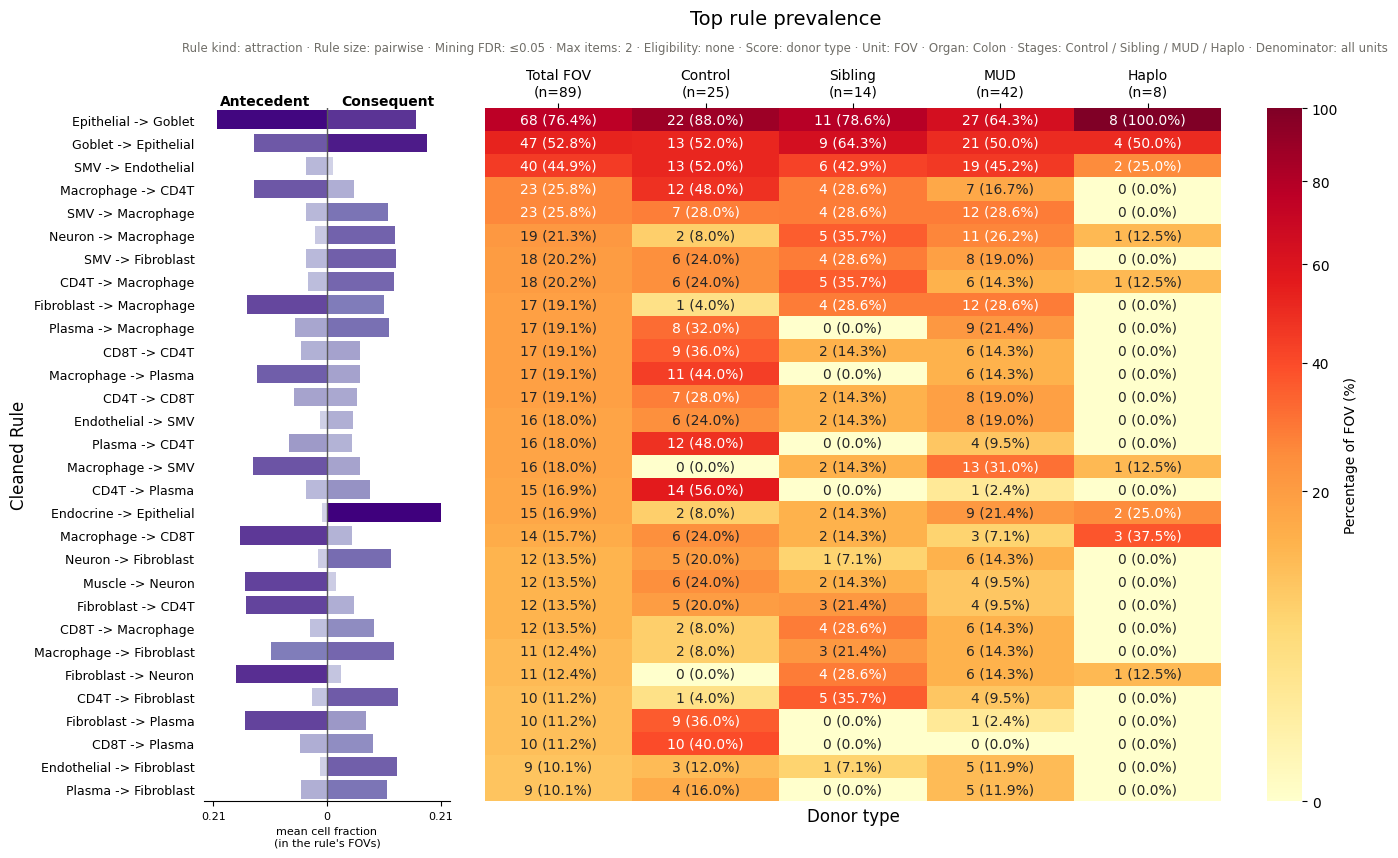

saved summary_downloads\overview_prevalence_donor_FOV_Duodenum_prevalence.pdf


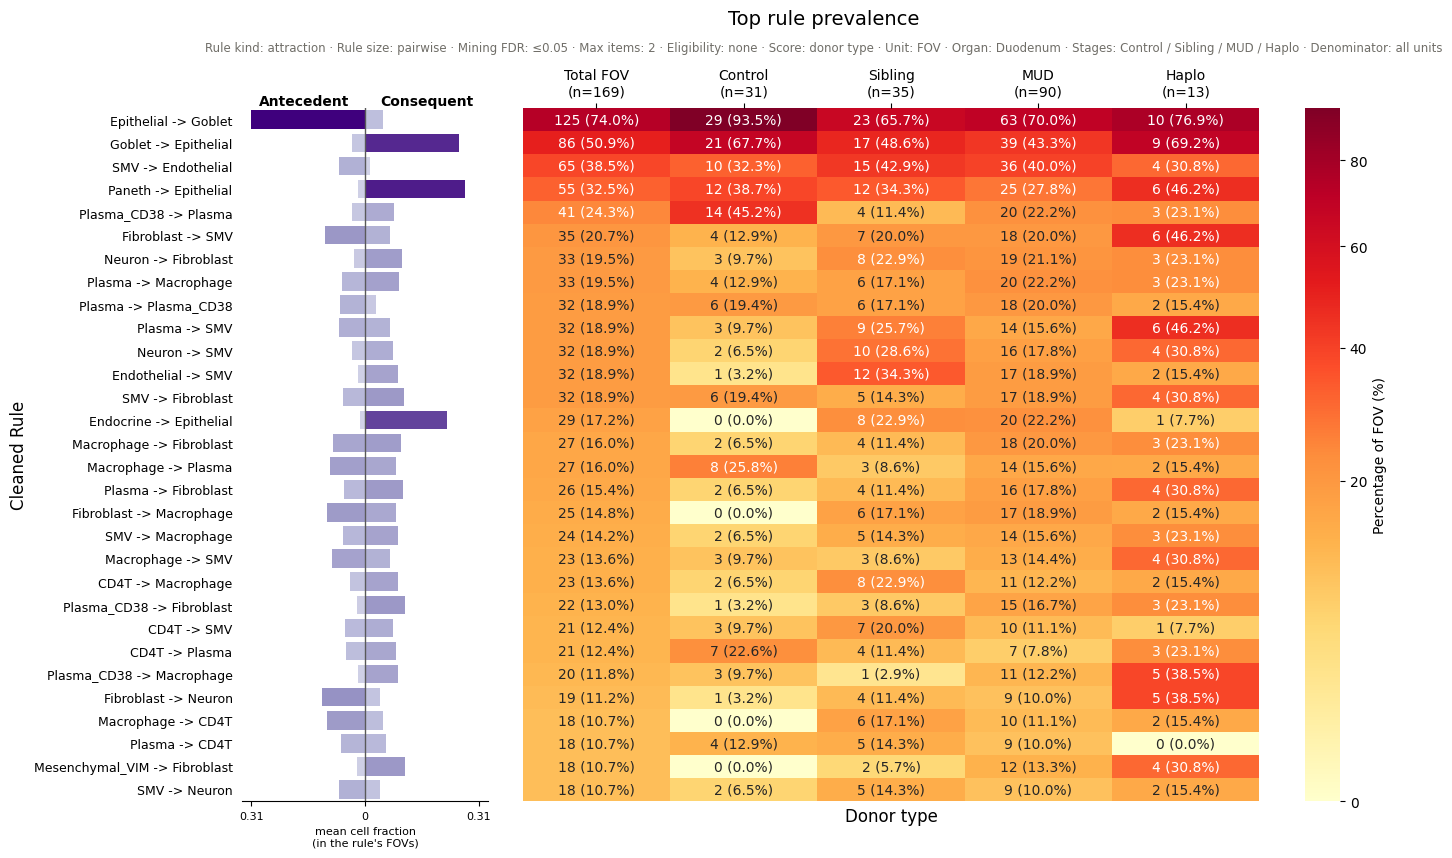

saved summary_downloads\overview_prevalence_cortico_FOV_Colon_prevalence.pdf


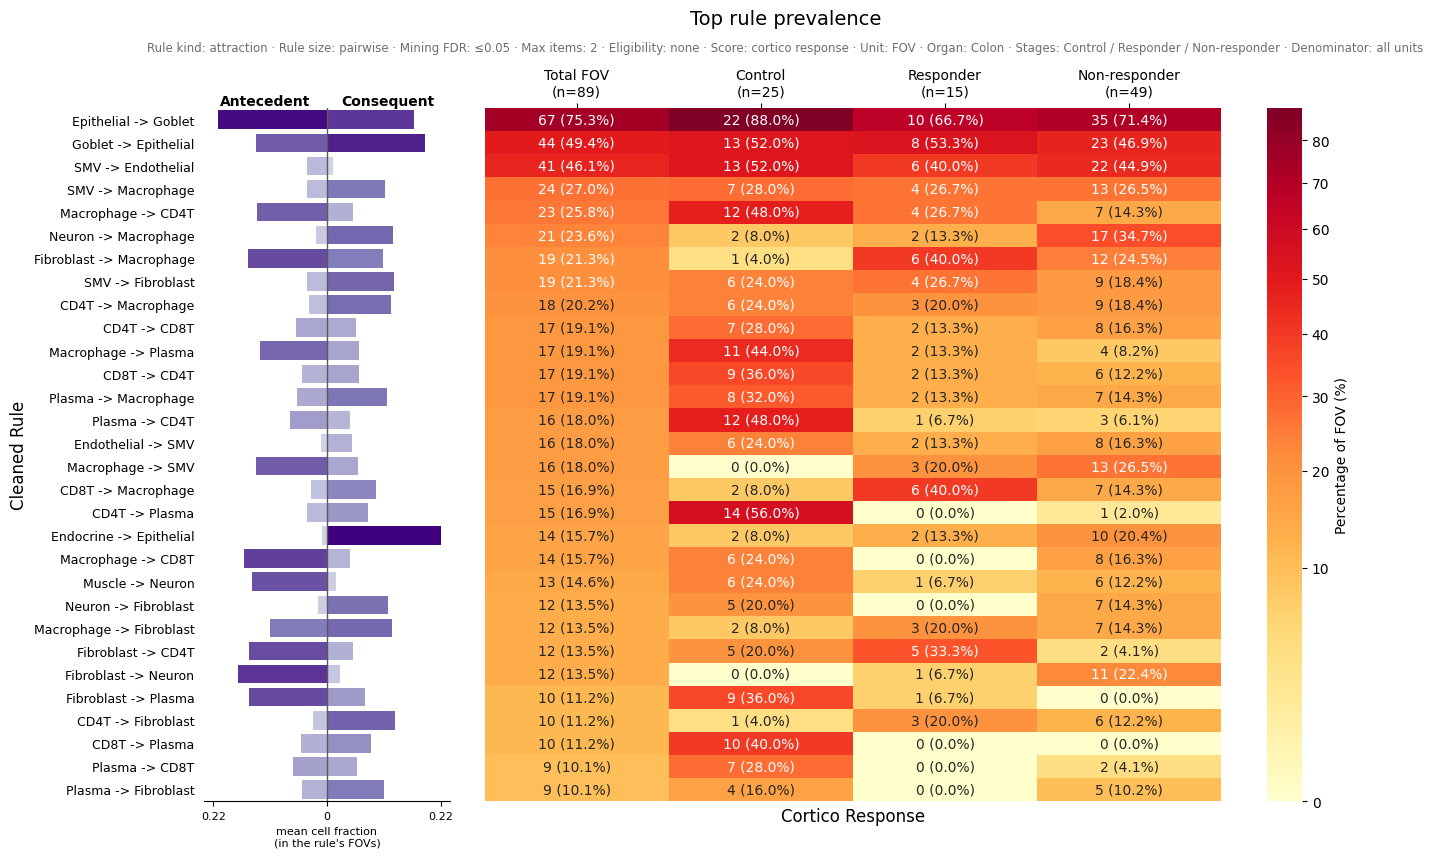

saved summary_downloads\overview_prevalence_cortico_FOV_Duodenum_prevalence.pdf


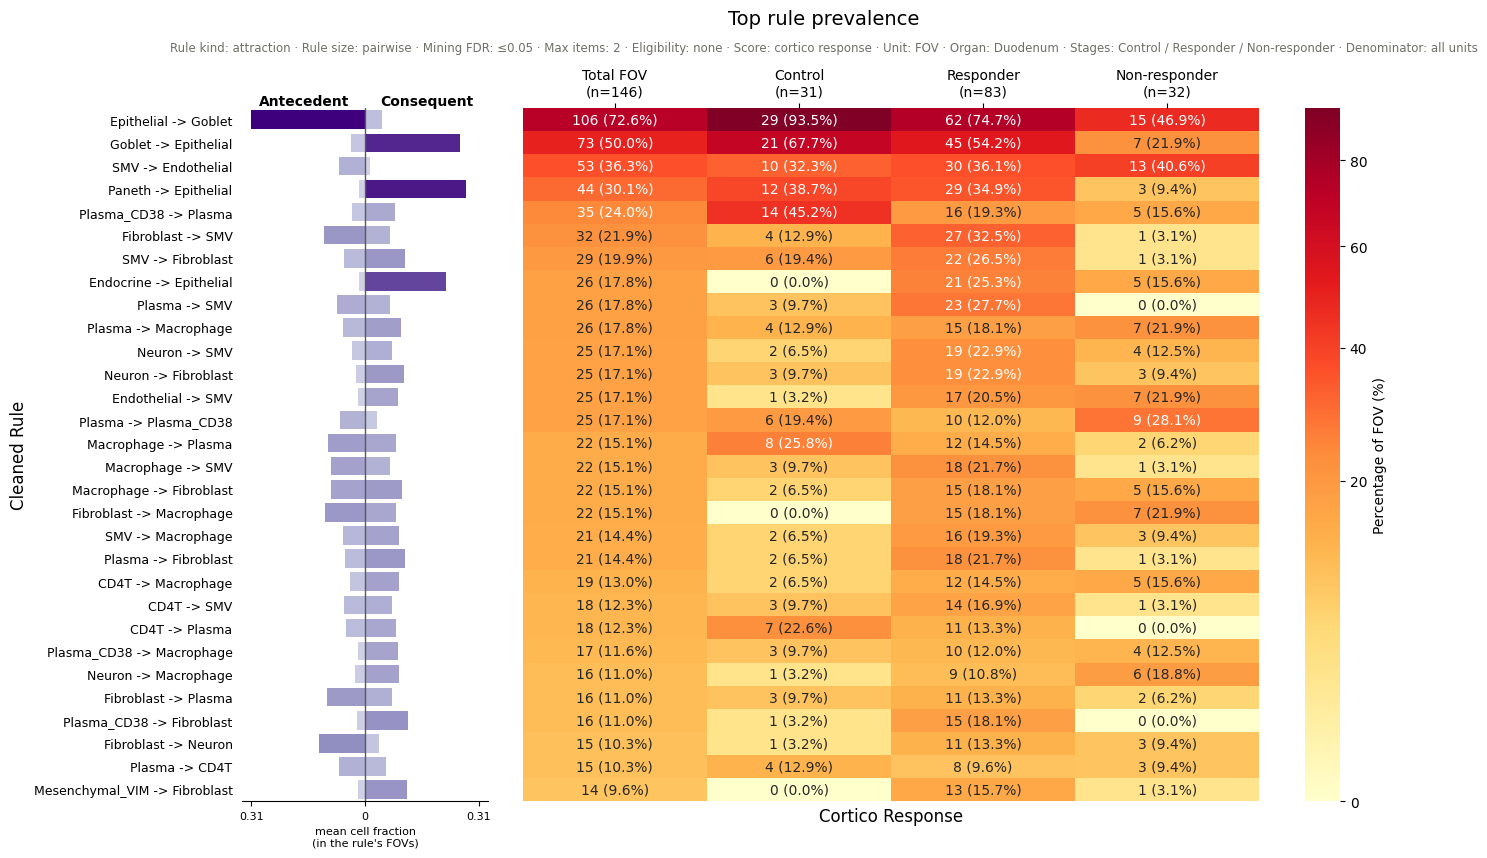

saved summary_downloads\overview_prevalence_survival_FOV_Colon_prevalence.pdf


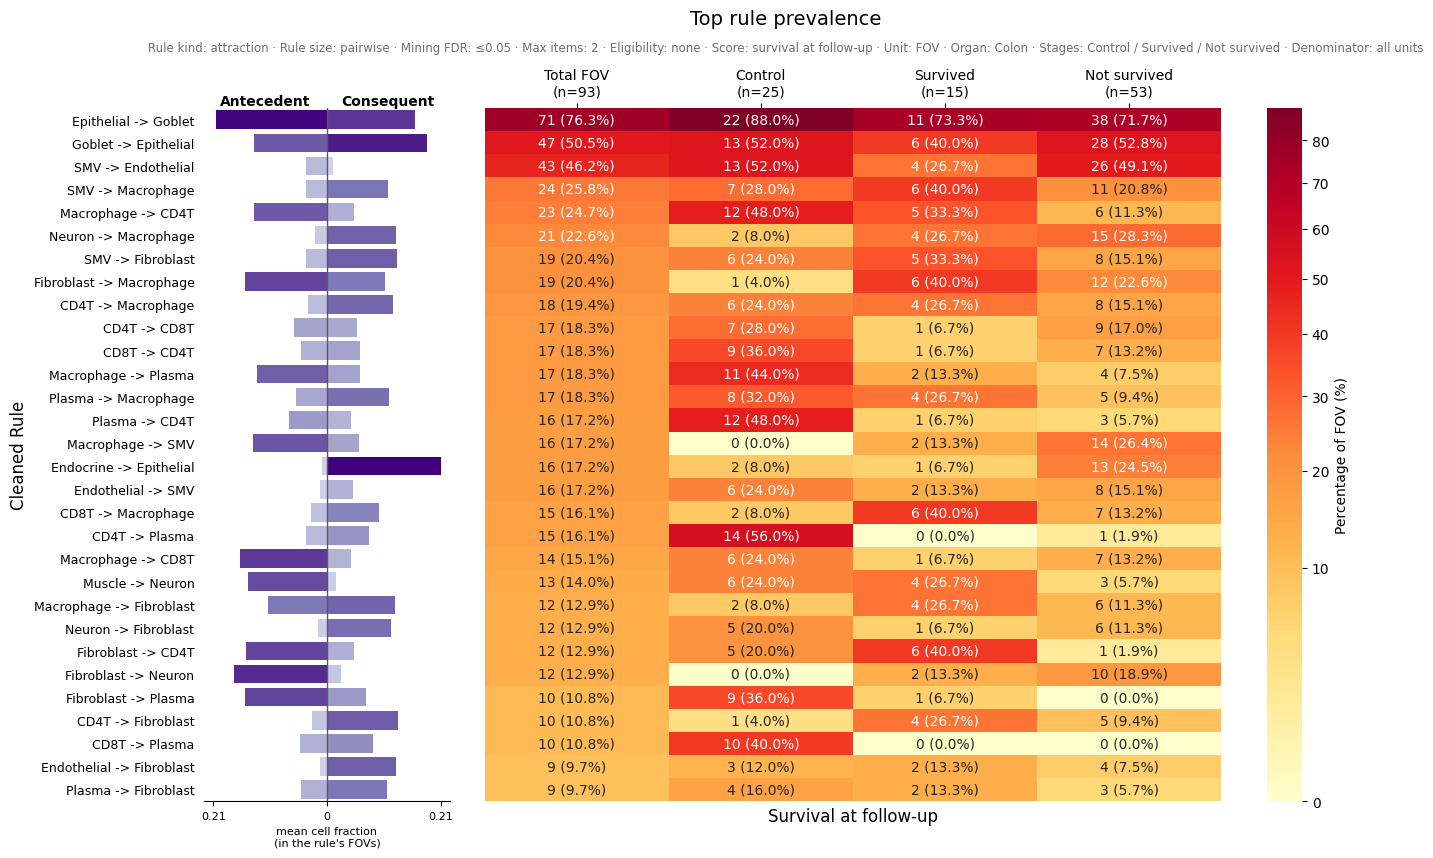

saved summary_downloads\overview_prevalence_survival_FOV_Duodenum_prevalence.pdf


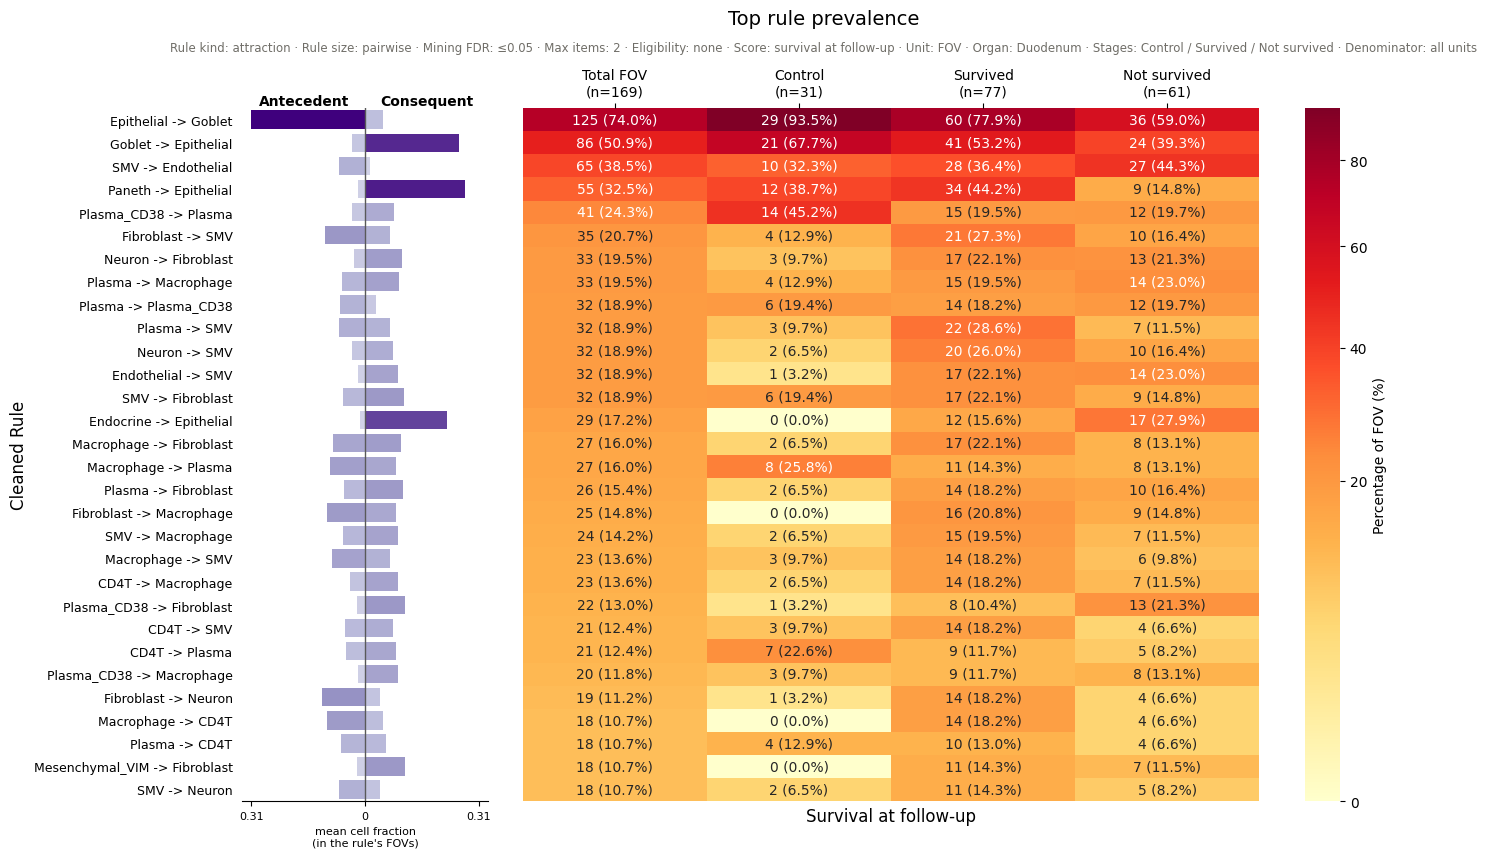

In [18]:
for column in METADATA_COLS:
    for organ in ("Colon", "Duodenum"):
        show_heatmap(
            score=column, organs=[organ], stage_order=METADATA_ORDER.get(column),
            show_abundance=True, drop_values=DROP_VALUES.get(column),
        )

## Patient fingerprints

saved summary_downloads\overview_fingerprint_patient_clinical_bothorgans.pdf


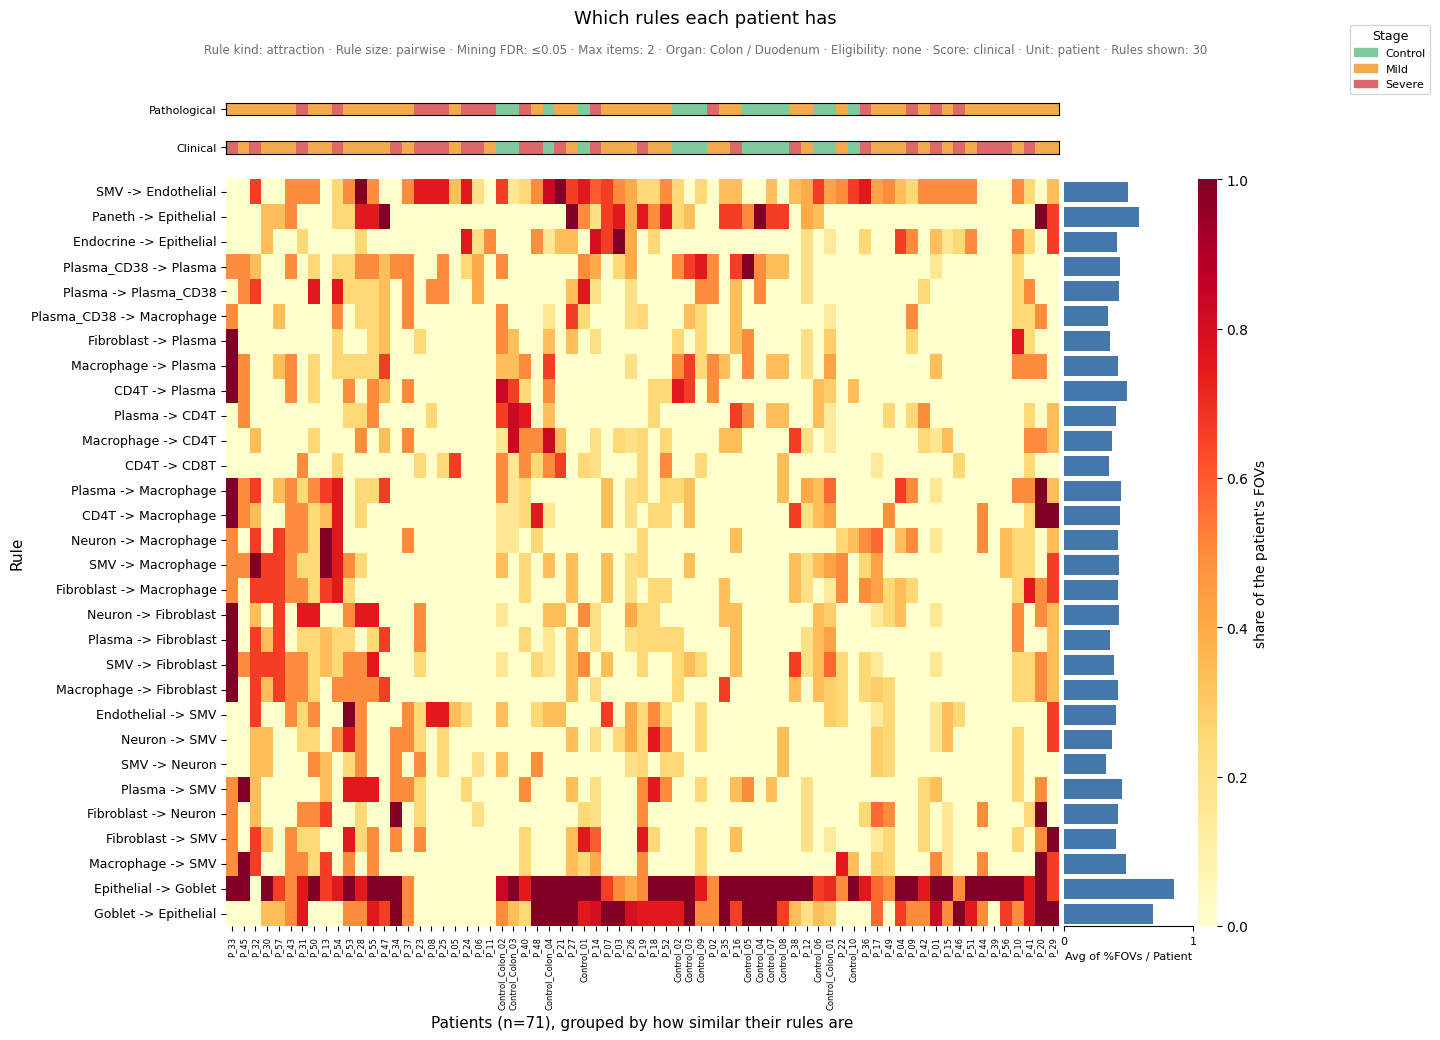

saved summary_downloads\overview_fingerprint_patient_clinical_Colon.pdf


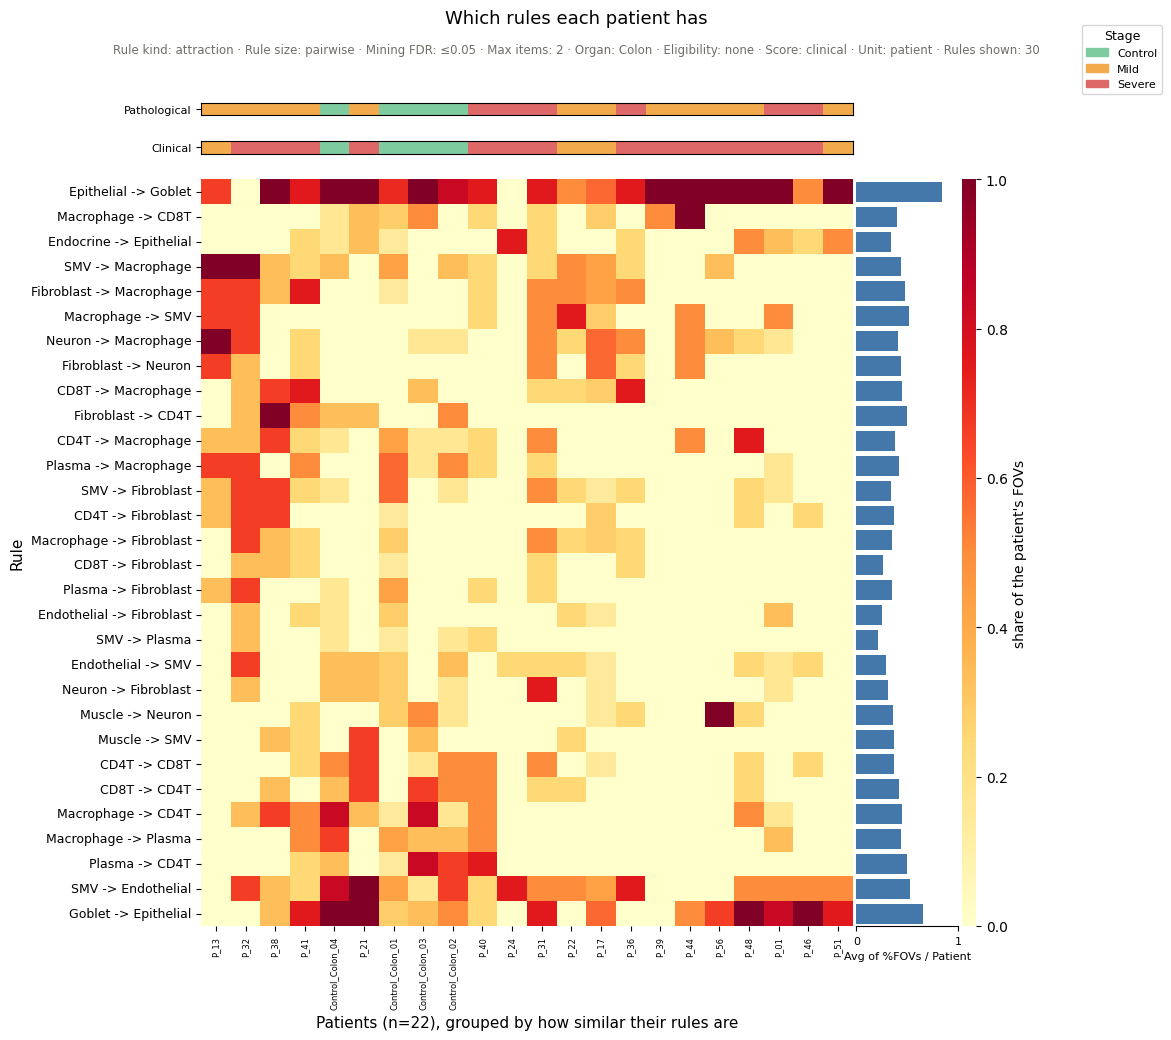

saved summary_downloads\overview_fingerprint_patient_clinical_Duodenum.pdf


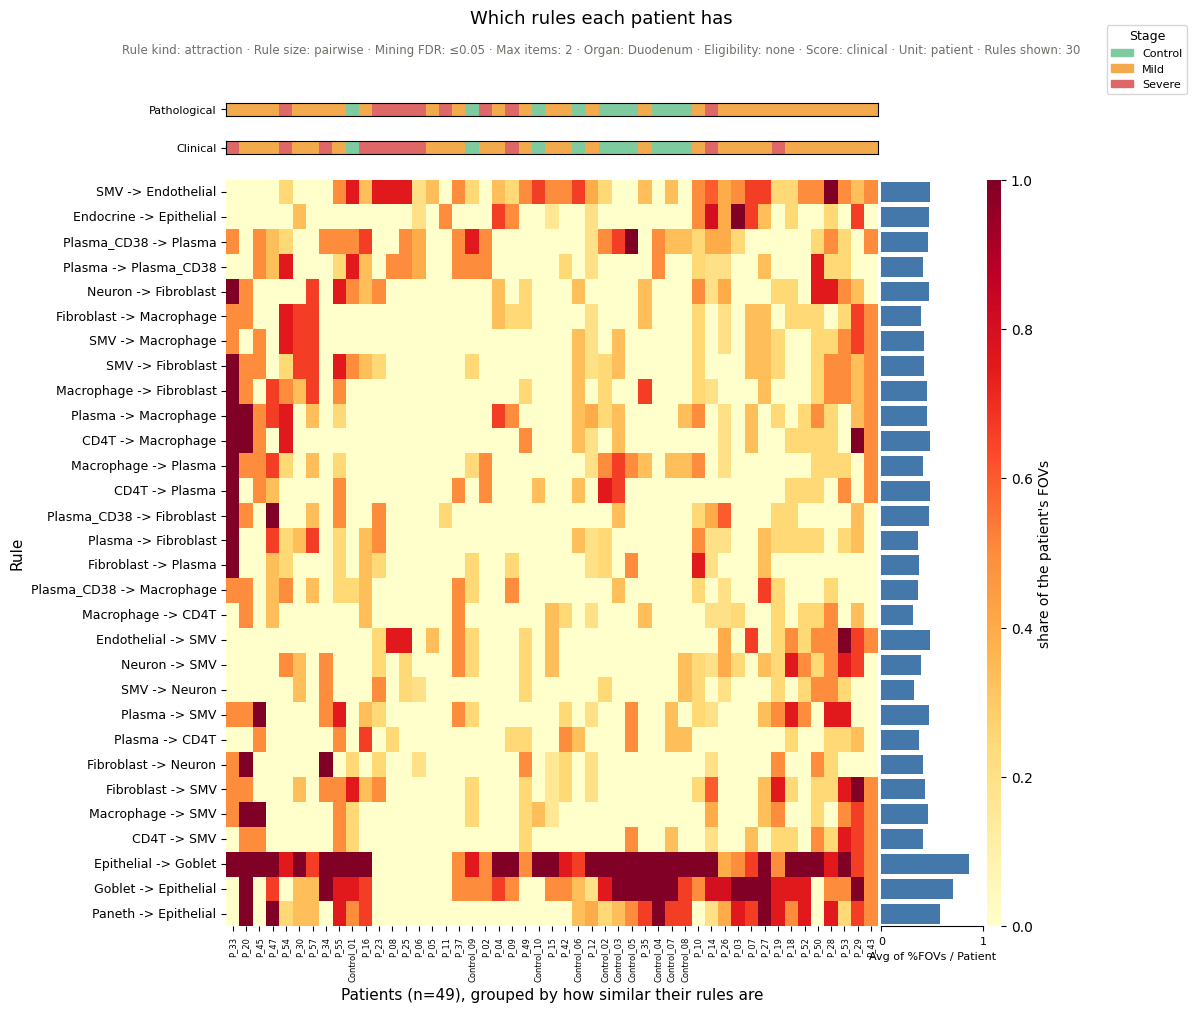

In [19]:
show_fingerprint(cluster_rules=True, show_consistency=True)
for organ in ("Colon", "Duodenum"):
    show_fingerprint(organs=[organ], cluster_rules=True, show_consistency=True)

## Reproducible rules

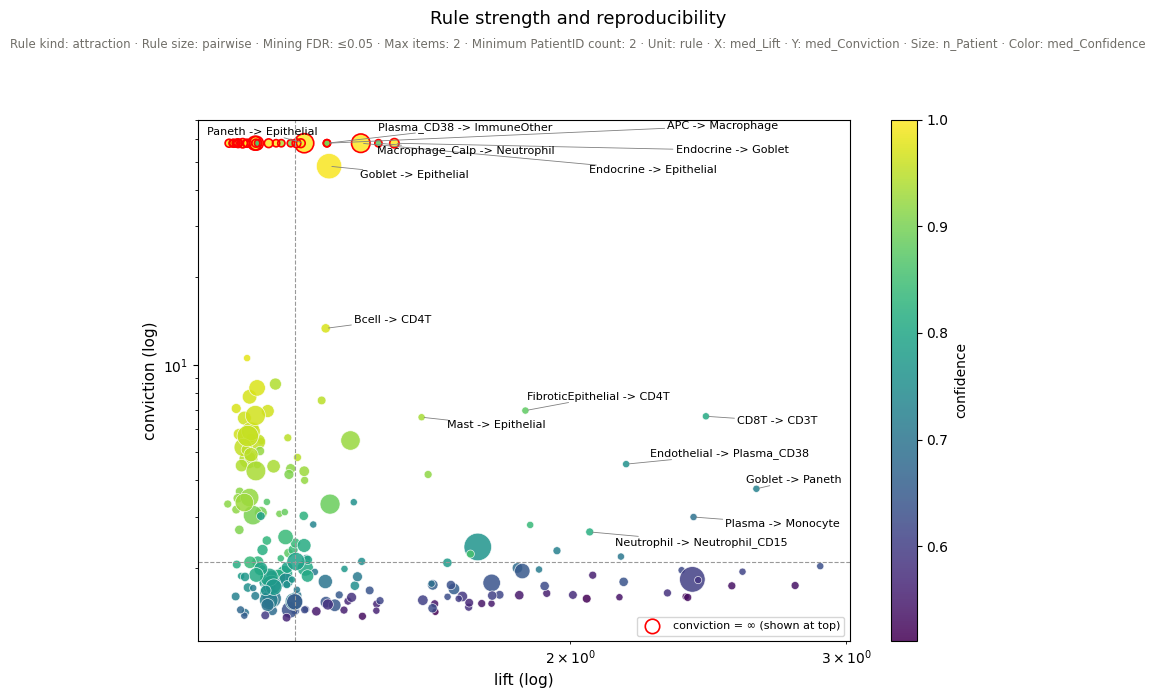

,antecedent,consequent,med_Lift,med_Confidence,med_Conviction,n_Patient,n_FOV,ant_abund,con_abund
Clean_Rule,,,,,,,,,
Goblet -> Paneth,Goblet,Paneth,2.629,0.725,3.739,2,2,0.013,0.090
CD8T -> CD3T,CD8T,CD3T,2.441,0.807,6.646,2,2,0.022,0.030
Plasma -> Monocyte,Plasma,Monocyte,2.397,0.692,2.988,2,2,0.025,0.015
Endothelial -> Plasma_CD38,Endothelial,Plasma_CD38,2.171,0.757,4.547,2,2,0.013,0.026
Neutrophil -> Neutrophil_CD15,Neutrophil,Neutrophil_CD15,2.057,0.818,2.655,3,3,0.074,0.026
FibroticEpithelial -> CD4T,FibroticEpithelial,CD4T,1.872,0.879,6.955,2,2,0.017,0.061
Mast -> Epithelial,Mast,Epithelial,1.607,0.934,6.596,2,2,0.009,0.185
Endocrine -> Goblet,Endocrine,Goblet,1.544,1.000,inf,5,8,0.010,0.152
Macrophage_Calp -> Neutrophil,Macrophage_Calp,Neutrophil,1.508,0.879,inf,2,2,0.012,0.104


In [20]:
REPRO_UNIT = "PatientID"
MIN_REPRO = 2
count_column = {"FOV": "n_FOV", "Biopsy": "n_Biopsy", "PatientID": "n_Patient"}[REPRO_UNIT]
repeated = rule_table[rule_table[count_column] >= MIN_REPRO]
named = plot_rule_metric_scatter(
    repeated, size_col=count_column, annotate_top=15,
    scope=f"{RULE_SCOPE} · Minimum {REPRO_UNIT} count: {MIN_REPRO}",
)
display(named)

## Metric and abundance

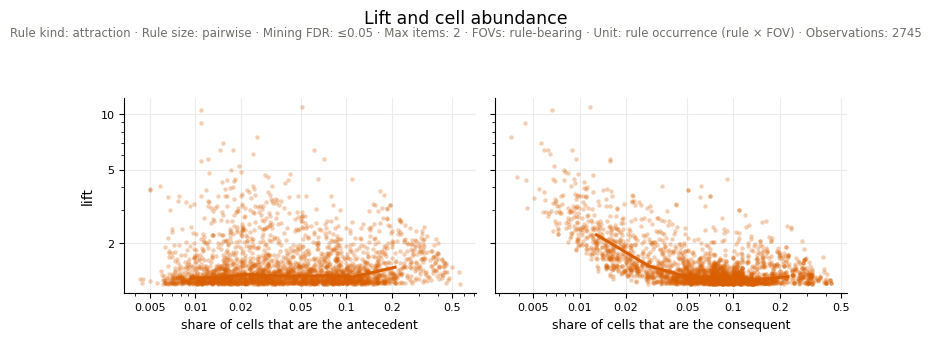

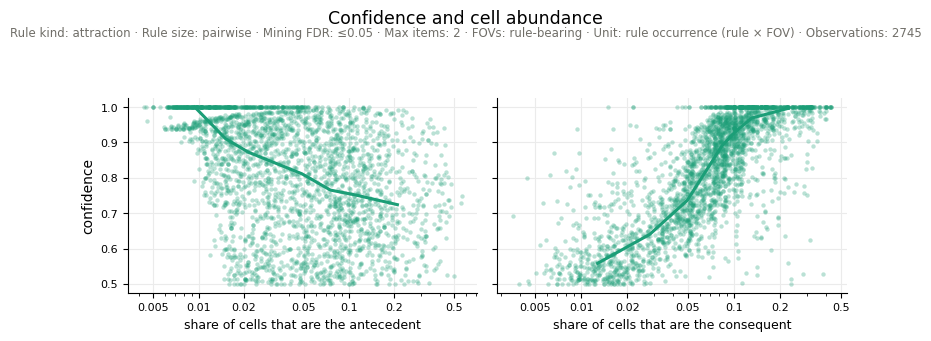

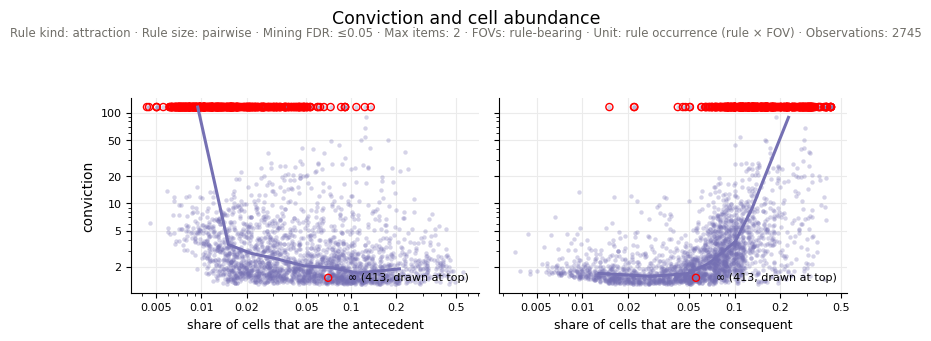

In [21]:
for metric in ("Lift", "Confidence", "Conviction"):
    plot_metric_vs_abundance(
        canon, FOV_FRAC, metric=metric,
        scope=f"{RULE_SCOPE} · FOVs: rule-bearing",
    )

## Abundance-ranked rules

saved summary_downloads\overview_prevalence_clinical_PatientID_bothorgans_ant.pdf


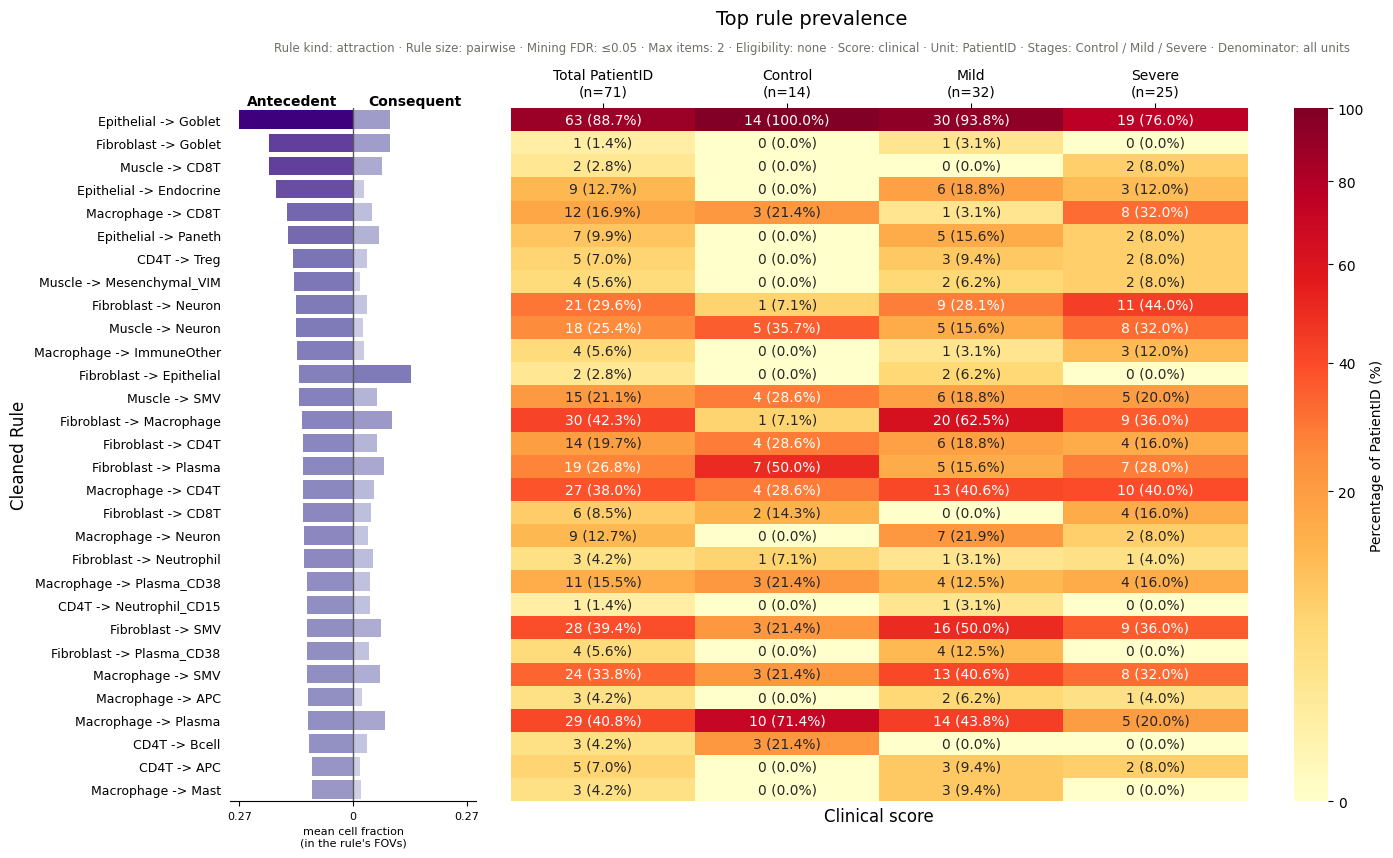

,antecedent,consequent,ant_abund,con_abund,n_Patient,med_Lift
Clean_Rule,,,,,,
Epithelial -> Goblet,Epithelial,Goblet,0.270,0.089,63,1.745
ImmuneOther -> Goblet,ImmuneOther,Goblet,0.011,0.347,1,1.254
Plasma_CD38 -> Epithelial,Plasma_CD38,Epithelial,0.016,0.288,6,1.241
Goblet -> Epithelial,Goblet,Epithelial,0.070,0.229,53,1.402
Paneth -> Epithelial,Paneth,Epithelial,0.019,0.270,29,1.352
Fibroblast -> Goblet,Fibroblast,Goblet,0.200,0.087,1,1.365
SMV -> Epithelial,SMV,Epithelial,0.020,0.259,3,1.244
Neuron -> Muscle,Neuron,Muscle,0.022,0.247,3,2.376
Muscle -> CD8T,Muscle,CD8T,0.199,0.069,2,1.326


In [22]:
show_heatmap(id_col="PatientID", show_abundance=True, sort_by="ant")
ranked = rule_table.assign(mean_abundance=rule_table[["ant_abund", "con_abund"]].mean(1))
display(ranked.nlargest(10, "mean_abundance")[
    ["antecedent", "consequent", "ant_abund", "con_abund", "n_Patient", "med_Lift"]
].round(3))

## Eligibility-controlled occurrence

saved summary_downloads\overview_eligible_prevalence_Colon.pdf


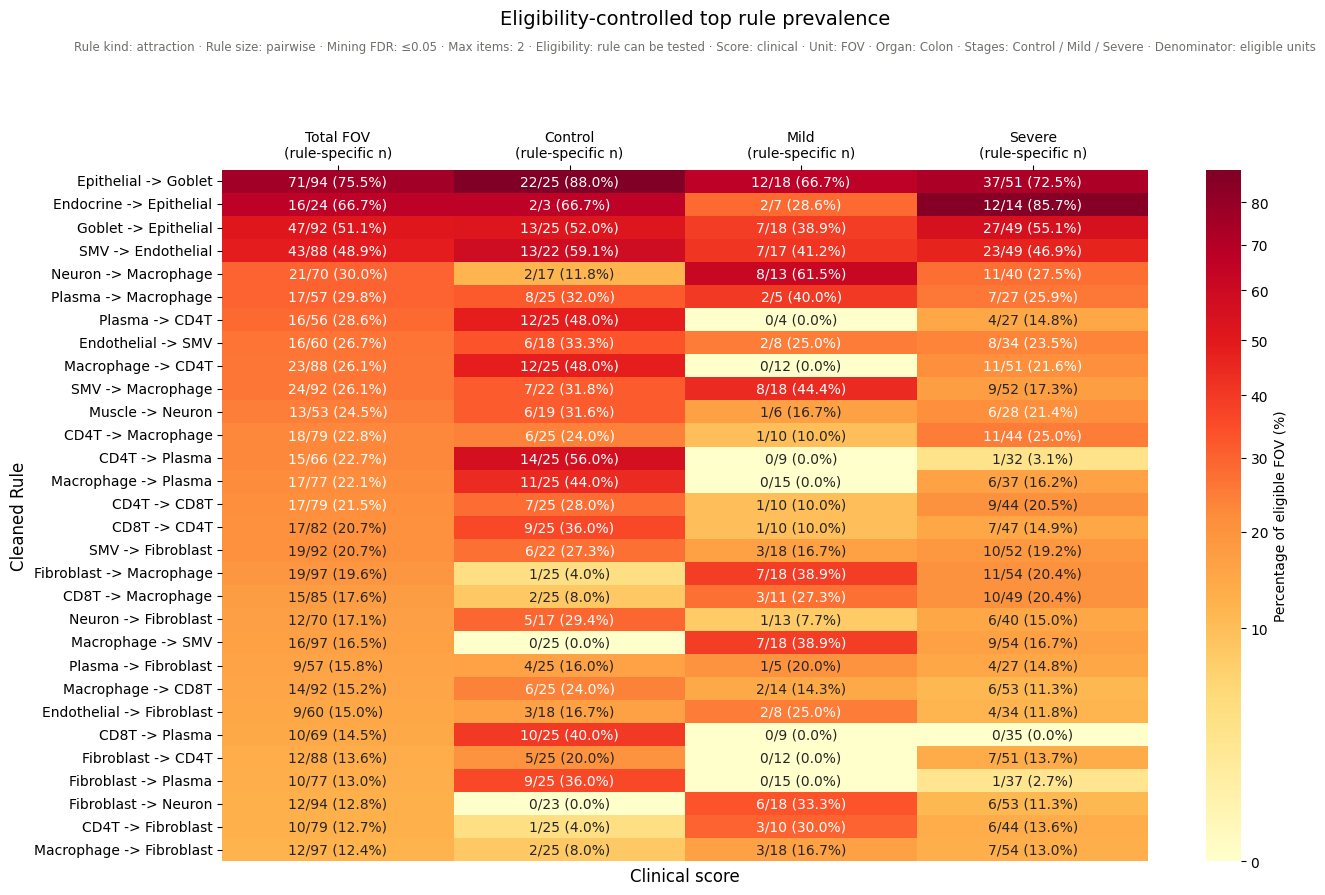

saved summary_downloads\overview_eligible_fingerprint_Colon.pdf


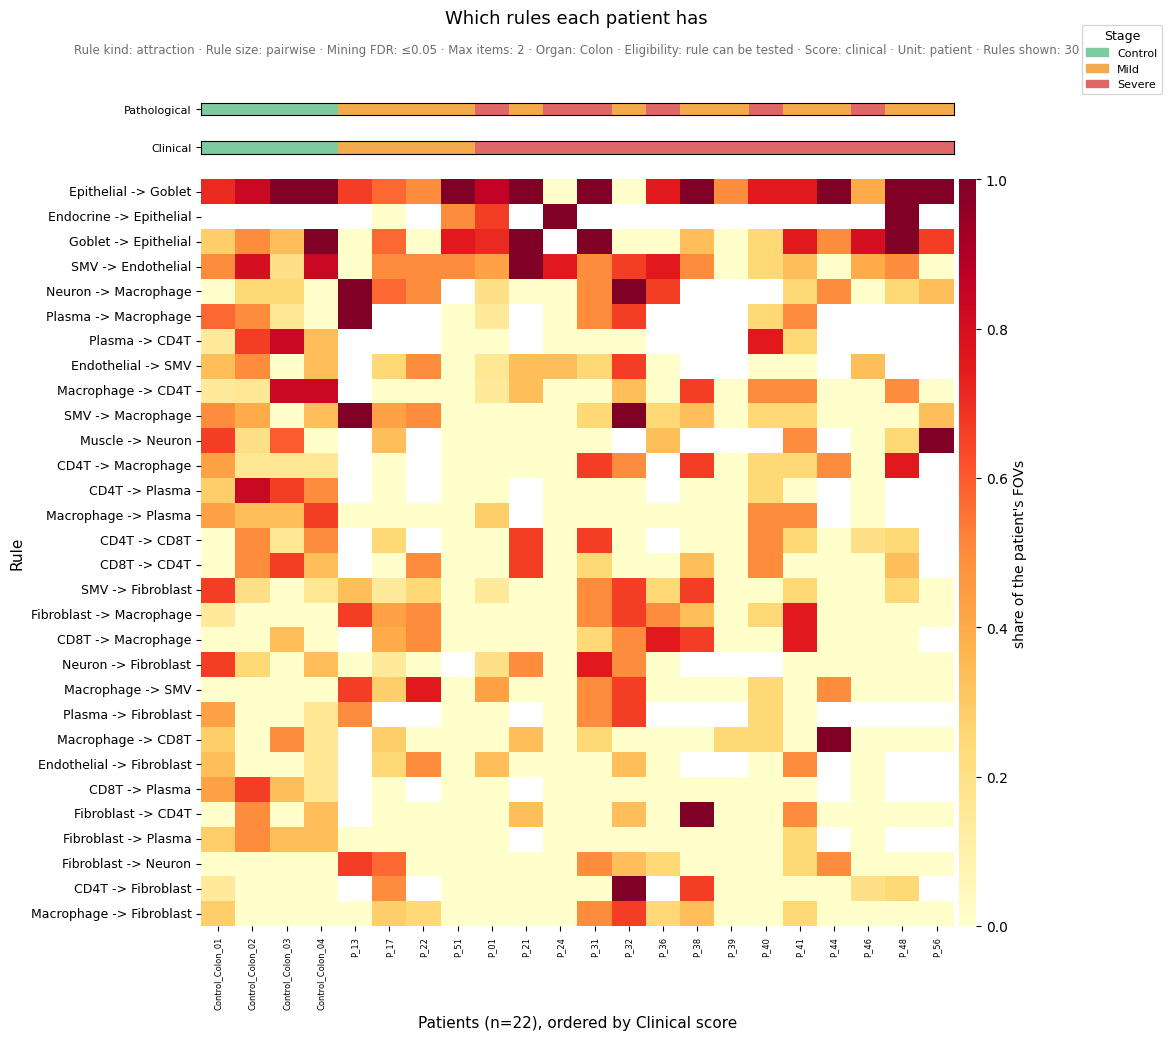

saved summary_downloads\overview_eligible_prevalence_Duodenum.pdf


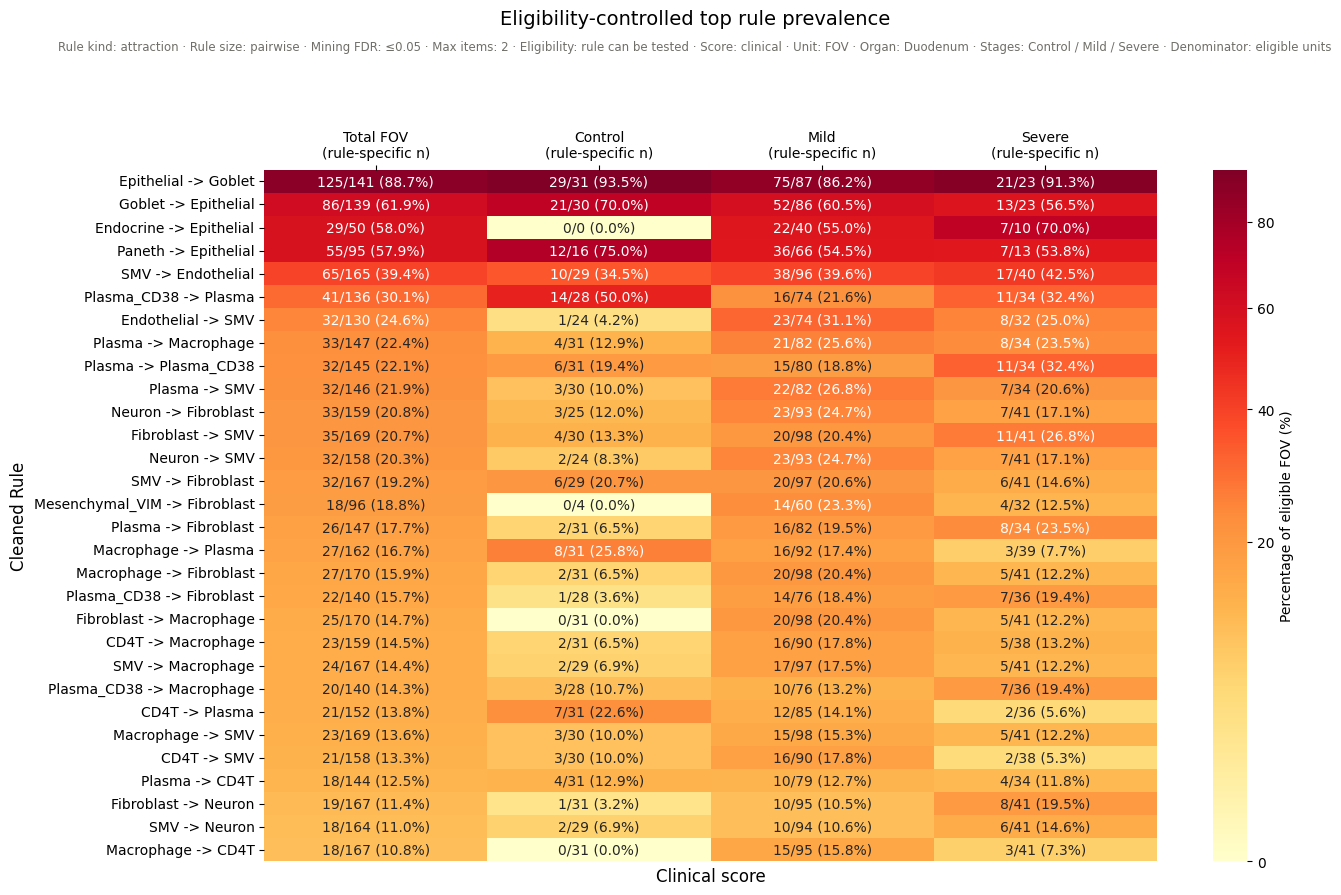

saved summary_downloads\overview_eligible_fingerprint_Duodenum.pdf


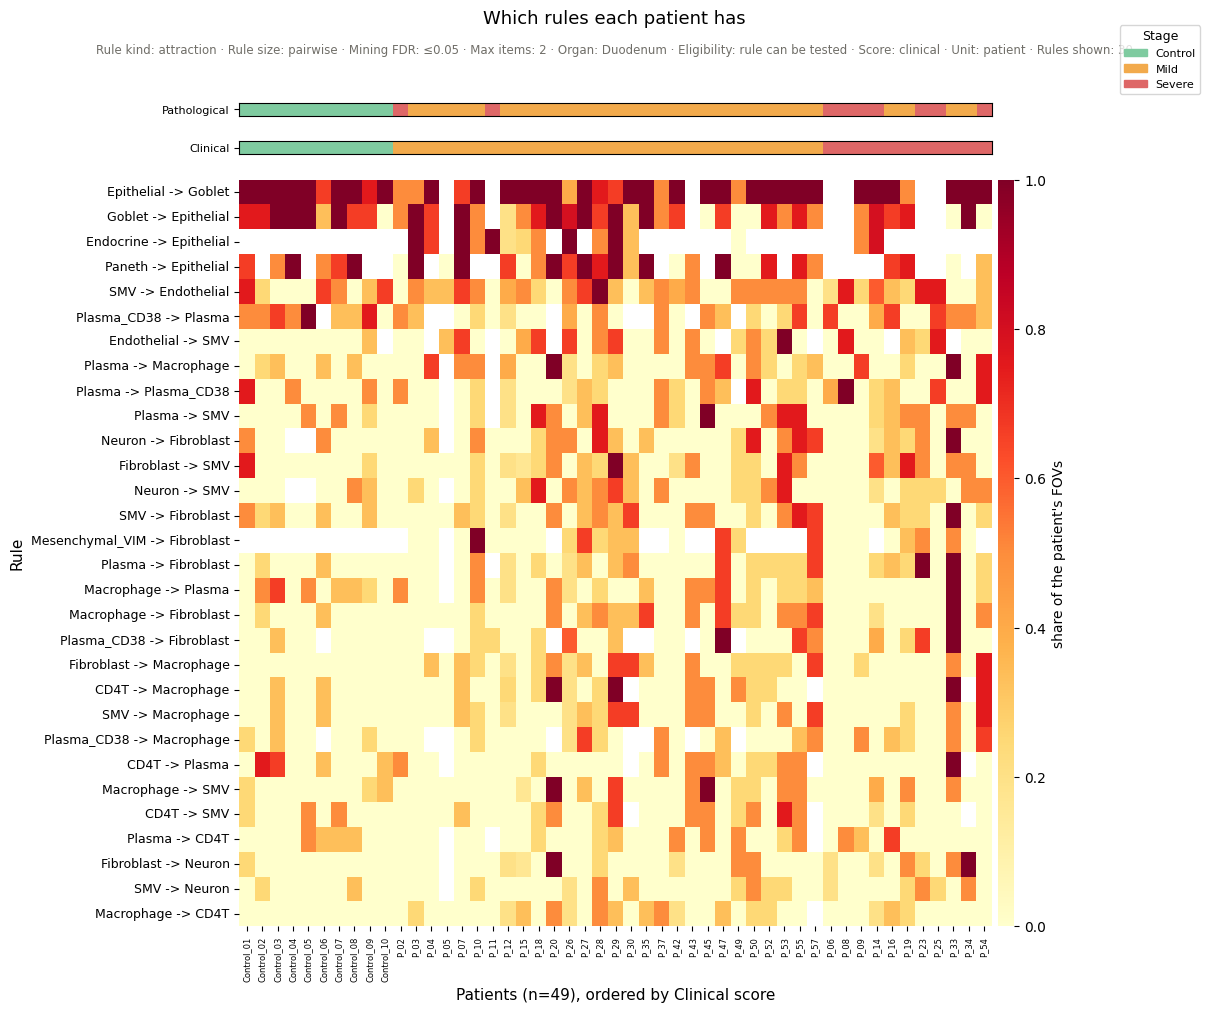

In [23]:
if USE_CELL_ELIGIBILITY:
    for organ in ("Colon", "Duodenum"):
        found, eligible, rows, meta, mask = eligible_occurrence(organ)
        plot_rule_stage_heatmap(
            found, meta, SCORE, organs=[organ], id_col="FOV",
            stage_order=STAGES, denominators=eligible, max_rules_to_show=TOP_RULES,
            scope=f"{RULE_SCOPE} · Eligibility: rule can be tested",
            save=figure_name("eligible_prevalence", organ),
        )
        selected = found.head(TOP_RULES).index
        fingerprint = eligible_patient_fingerprint(rows, meta, selected, mask)
        plot_patient_fingerprint(
            fingerprint, meta, SCORE, stage_order=STAGES, order="stage",
            max_rules=TOP_RULES,
            scope=f"{RULE_SCOPE} · Organ: {organ} · Eligibility: rule can be tested",
            save=figure_name("eligible_fingerprint", organ),
        )